## Анализ пользовательского спроса и активности на платформе Яндекс Афиши.

Автор: Макарова Елена

Дата: 18.09.2025 г.

## Цели и задачи проекта


**Цель проекта**


Цель данного проекта — провести исследовательский анализ данных сервиса бронирования билетов Яндекс Афиши за период с 1 июня по 30 ноября 2024 года, чтобы выяснить причины изменений в пользовательском спросе, определить ключевые факторы, влияющие на популярность мероприятий, и проанализировать активность пользователей, как с мобильных, так и с десктопных устройств. В результате анализа будет произведено сравнение сезонных изменений, выделение лидеров по выручке, а также определены особенности поведения пользователей в зависимости от различных факторов, таких как тип мероприятия, устройство, возрастное ограничение и прочее.



**Задачи проекта**


1. Загрузить и подготовить данные: Анализ и подготовка данных для дальнейшего исследования, включая проверку на пропуски, дубликаты, преобразование валют и создание новых столбцов, таких как выручка в рублях, выручка с одного билета и информация о сезонности.


2. Провести Исследовательский анализ данных: Изучение распределения заказов по различным сегментам (тип мероприятия, тип устройства, категория по возрастному рейтингу) и анализ их сезонных изменений. Включает расчет средней выручки с одного билета, а также сравнение летнего и осеннего периодов.


3. Проанализировать активность пользователей осенью 2024 года: Анализ динамики заказов, количества активных пользователей (DAU), средней активности пользователей и выявление недельной цикличности.


4. Исследовать популярность событий и партнеров осенью 2024 года: Определение наиболее популярных мероприятий, анализ выручки по регионам и партнерам, а также выявление лидеров по количеству мероприятий и заказов.


5. Проверить гипотезы: Статистический анализ для проверки гипотез о более высокой активности пользователей мобильных приложений по сравнению с десктопными, включая использование соответствующих статистических тестов.


6. Сформулировать общий вывод и рекомендации: Описание основных результатов исследования, анализ трендов, выявление лидеров среди регионов и партнеров, а также предложения по улучшению пользовательского опыта и предложения по дальнейшему развитию сервиса.

## Описание данных

В рамках этого проекта мы будем изучать данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года.

Данные представлены в двух датасетах `final_tickets_orders_df.csv` и `final_tickets_events_df.csv`.

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 

- `order_id` — уникальный идентификатор заказа.

- `user_id` — уникальный идентификатор пользователя.

- `created_dt_msk` — дата создания заказа (московское время).

- `created_ts_msk` — дата и время создания заказа (московское время).

- `event_id` — идентификатор мероприятия из таблицы events.

- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.

- `age_limit` — возрастное ограничение мероприятия.

- `currency_code` — валюта оплаты, например rub для российских рублей.

- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.

- `revenue` — выручка от заказа.

- `service_name` — название билетного оператора.

- `tickets_count` — количество купленных билетов.

- `total` — общая сумма заказа.

В данные также был добавлен столбец `days_since_prev` с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.


Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:

- `event_id` — уникальный идентификатор мероприятия.

- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.

- `event_type_description` — описание типа мероприятия.

- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.

- `organizers` — организаторы мероприятия.

- `region_name` — название региона.

- `city_name` — название города.

- `venue_id` — уникальный идентификатор площадки.

- `venue_name` — название площадки.

- `venue_address` — адрес площадки.


Также в нашем распоряжении будет датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. 

Датасет `final_tickets_tenge_df.csv`содержит такие поля:

- `nominal` — номинал (100 тенге);

- `data` — дата;

- `curs` — курс тенге к рублю;

- `cdx` — обозначение валюты (kzt).


## Содержимое проекта

1. [Загрузка данных и знакомство с ними.](#якорь1)
2. [Смена типов данных и анализ пропусков](#якорь2)
3. [Анализ выбросов.](#якорь3)
4. [Проверка дубликатов.](#якорь4)
5. [Создание новых столбцов и подсчет основных метрик](#якорь5)
6. [Промежуточный вывод](#якорь6)
7. [Исследовательский анализ данных](#якорь7)
8. [Статистический анализ данных](#якорь8)
9. [Общий вывод](#якорь9)


<a id='якорь1'></a>
## 1. Загрузка данных и знакомство с ними.


In [1]:
# Импортируем библиотеки
import pandas as pd

# Импортируем библиотеки matplotlib и seaborn для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем библиотеку для численных вычислений 
import numpy as np

# Импорт функции теста Манна — Уитни из библиотеки scipy.stats

from scipy.stats import mannwhitneyu

# Импорт функции округления в большую сторону из модуля math
from math import ceil


Загрузим данные о заказах билетов из файла `final_tickets_orders_df.csv`:

In [2]:
# Выгружаем данные в датафрейм 
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

# Выводим первые строки датафрейма на экран
orders.head()


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [3]:
# Выводим информацию о датасете
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет содержит 290849 строк и 14 столбцов с информацией о идентификаторах пользователей, заказов, событий, возрастном ограничении, дате и времени события, валюте, выручке, названии сервиса, типе устройства, количестве дней с предыдущей покупки. Содержание соответствует заявленным данным.

**Типы данных**


- order_id, event_id, age_limit и tickets_count - содержат целочисленные данные и представлены типм int64, что корректно. Для нормализации данных у столбцов age_limit и tickets_count можно понизить размерность до int8.


- user_id, cinema_circuit, currency_code, device_type_canonical, service_name - содержат как строковые, так и числовые данные, поэтому тип object для таких данных подходит.


- revenue, total - содержат информацию о выручке и хранят дробные числовые данные, представленные типом float64, что корректно.


- days_since_prev - содержит инвормацию о днях и представлен целочисленными данными, но хранится в типе float64. Для хранения таких данных больше подходит int64.


- created_dt_msk, created_ts_msk - содержат данные о дате и времени, представленные типом object. Для таких данных больше подойдёт тип datetime64. 

**Пропуски**

Столбец days_since_prev содержит пропуски.В остальных столбцах датасета `final_tickets_orders_df.csv` пропусков не наблюдается.





Загрузим данные о событиях из файла `final_tickets_events_df.csv`:

In [4]:
# Выгружаем данные в датафрейм 
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

# Выводим первые строки датафрейма на экран
events.head()


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
# Выводим информацию о датасете
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB



Датасет содержит 22427 строки и 11 столбцов с информацией о идентификаторах событий и площадок, их названиях, типах, а также информацию о геоположении площадок.Содержание соответствует заявленным данным.


**Типы данных**


- event_id, city_id, venue_id - содержат целочисленные данные и представлены типм int64, что корректно.


- event_name, event_type_description, event_type_main, organizers, region_name, city_name, venue_name, venue_address содержат как строковые, так и числовые данные, поэтому тип object для таких данных подходит.

**Пропуски**

В столбцах датасета `final_tickets_event_df.csv` пропусков не наблюдается.




In [6]:
# Выгрузим данные из таблицы final_tickets_tenge_df.csv
df_exchange = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# Выведем информацию
df_exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [7]:
# Выведем первые пять строк
df_exchange.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Датасет содержит 357 строки и 4 столбца, в которых содержится информация о дате, о виде валюты (KZT) и о номинале. Содержание соответствует заявленным данным.

- data содержит  данные о дате, представленные типом object. Для таких данных больше подойдёт тип datetime64.

- nominal содержит целочисленные данные и представлены типм int64, что корректно. Для нормализации данных можно понизить размерность до int8.	

- curs хранит дробные числовые данные, представленные типом float64, что корректно.

- cdx содержит строковые данные и представлены типом object, что корректно.

Пропусков нет.

<a id='якорь2'></a>
## 2. Смена типов данных и анализ пропусков

Посчитаем количество пропусков в столбце days_since_prev датасета `final_tickets_orders_df.csv` в абсолютных и относительных значениях:

In [8]:
missing_stats = pd.DataFrame({'Кол-во пропусков': orders.isnull().sum(),
                              'Доля пропусков':orders.isnull().mean().round(4)})
missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"

,Кол-во пропусков,Доля пропусков
days_since_prev,21940,0.075400


В days_since_prev содержится 21940 пропуск, что составляет 7,5 %. В данном столбце содержится информация с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск. Поэтому заполнять пропуски мы не будем.


**Для оптимизации данных преобразуем их в нужный тип:**

При помощи метода `to_datetime()` преобразуем столбцы created_dt_msk, created_ts_msk датасета `final_tickets_orders_df.csv` из строкового формата в формат datetime64

In [9]:
# При помощи цикла преобразуем столбцы к datetime64
for column in ['created_dt_msk', 'created_ts_msk']:
    orders[column] = pd.to_datetime(orders[column])

In [10]:
# Проверка типа данных
display(orders[['created_dt_msk', 'created_ts_msk']].dtypes)

created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object

Переведем данные столбца data датасета `final_tickets_tenge_df.csv` из строкового формата к нужному типу datetime64:

In [11]:
# Преобразование столбца в datetime64
df_exchange['data'] = pd.to_datetime(df_exchange['data'])

# Проверка типа данных
display(df_exchange['data'].dtype)

dtype('<M8[ns]')

- Все столбцы преобразованы к нужному типу данных.

Для оптимизации хранения в столбцах age_limit и tickets_count понизим размерность до int8

In [12]:
# При помощи цикла понизим размерность с int64 на int8
for column in ['age_limit', 'tickets_count']:
    orders[column] = orders[column].astype('int8')

In [13]:
# Проверка типа данных
print(orders[['age_limit', 'tickets_count']].dtypes)

age_limit        int8
tickets_count    int8
dtype: object


Для оптимизации хранения в столбце nominal понизим размерность до int8:

In [14]:
# Понизим размерность с int64 на int8
df_exchange['nominal'] = df_exchange['nominal'].astype('int8') 

# Проверка типа данных
print(df_exchange['nominal'].dtype)

int8


- Столбцы успешно приведены к необходимой размерности.

**Объединим датафреймы `orders` и `events` по столбцу event_id.**

Используем INNER JOIN, поэтому сохранятся только те записи, для которых есть соответствие в обоих датафреймах.

Новый датафрейм будет содержать все столбцы из `orders` и все столбцы из `events` (кроме дублирующегося event_id).

In [15]:
# Выполняем объединение по event_id
df = orders.merge(events, on='event_id', how='inner')

# Проверяем результат
print(f"Размер исходного orders: {orders.shape}")
print(f"Размер объединенного датафрейма: {df.shape}")
df.info()

Размер исходного orders: (290849, 14)
Размер объединенного датафрейма: (290611, 24)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int64         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  int8          
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float64       
 10  service_name            290611 non-null  object        
 11  tickets

Посчитаем пропуски в объединенном датафрейме:

In [16]:
missing_stats = pd.DataFrame({'Кол-во пропусков': df.isnull().sum(),
                              'Доля пропусков':df.isnull().mean().round(4)})
missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"

,Кол-во пропусков,Доля пропусков
days_since_prev,21913,0.075400


В датафрейме df содержатся пропуски только в столбце days_since_prev - 21940 пропуск, что составляет 7,5 %. В данном столбце содержится информация с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск. Поэтому заполнять пропуски мы не будем.

<a id='якорь3'></a>
## 3. Анализ выбросов.

- Изучаем статистические показатели столбца `tickets_count`. Для этого используем метод describe():

In [17]:
# Изучаем статистические показатели столбца 
print('Статистические показатели столбца tickets_count:')
df['tickets_count'].describe().to_frame().style.format('{:.0f}')

Статистические показатели столбца tickets_count:


,tickets_count
count,290611
mean,3
std,1
min,1
25%,2
50%,3
75%,4
max,57


**Анализ статистических показателей столбца tickets_count:**


- Общее количество записей (count): В наборе данных содержится 290611 записей, что указывает на большой объем данных для анализа.


- Среднее значение (mean): Среднее количество билетов в заказе составляет 3 билета. Это говорит о том, что в среднем заказы включают небольшое количество билетов.


- Стандартное отклонение (std): Стандартное отклонение равно 1, что указывает на низкую вариабельность данных. Большинство заказов имеют количество билетов, близкое к среднему значению (3).


- Минимальное значение (min): Минимальное количество билетов в заказе — 1. 


- 25% (первый квартиль): 25% заказов содержат 2 или меньше билетов.


- 50% (медиана): Половина заказов имеет 3 билета, что совпадает со средним значением, указывая на симметричное распределение данных вокруг медианы.


- 75% (третий квартиль): 75% заказов содержат 4 или меньше билетов. Это подтверждает, что большинство заказов включает небольшое количество билетов.


- Максимальное значение (max): Максимальное количество билетов в заказе — 57. Это значительно выше среднего значения и указывает на наличие редких заказов с большим количеством билетов, которые могут быть выбросами.


**Вывод:**

Распределение количества билетов в заказах (tickets_count) в основном сосредоточено вокруг 2–4 билетов, с медианой и средним значением, равным 3. Низкое стандартное отклонение говорит о том, что данные достаточно однородны, а заказы с большим количеством билетов (например, 57) являются редкими исключениями. Для более глубокого анализа можно рассмотреть распределение данных и выявить, являются ли заказы с большим числом билетов аномалиями или связаны с определенными категориями клиентов (например, групповыми поездками).





Построим гистограмму распределения значений и диаграмму размаха для столбца tickets_count:

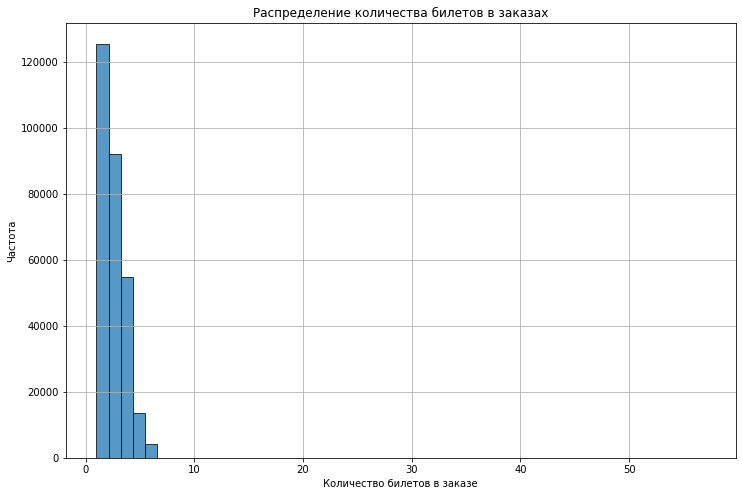

In [18]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 8))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['tickets_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин 
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества билетов в заказах')
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Наблюдается ненормальное распределении с правосторонней асимметрией (смещено вправо из-за выбросов).

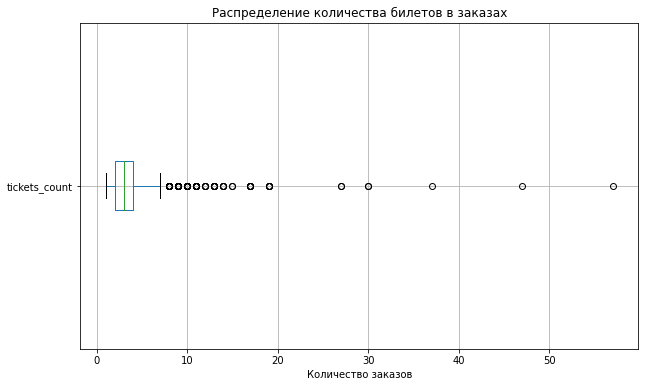

In [19]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества билетов в заказах')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

- Диаграмма показывает правосторонную ассиметрию с наличием выбросов, значения от 8 до 57 билетов. Выбросы составляют небольшую долю данных, но указывают на редкие нетипичные заказы.

- Основная масса данных распределена в диапазоне 1-7 билетов. Больше всего данных в районе 2-4 билетов.



Так как выбросы составляют незначительную долю данных  к существенному искажению они не приведут, и их можно удалить. Оставим значения, которые будут меньше 99%-го процентиля этого ряда значений или равны ему. Для вычислений используем метод quantile() и построим распределение по набору значений, очищенному от выбросов:

In [20]:
# Сохраняем исходный размер датафрейма
original_size = df.shape[0]

# Вычисляем пороговое значение 
threshold = df['tickets_count'].quantile(0.99)

# Удаляем строки с значениями выше порога
df = df[df['tickets_count'] <= threshold]

# Проверяем результат
new_size = df.shape[0]
removed_rows = original_size - new_size
removed_percentage = (removed_rows / original_size) * 100

display(f"Исходный размер датафрейма: {original_size}")
display(f"Новый размер датафрейма: {df.shape[0]}")
display(f"Количество удаленных строк: {removed_rows}")
display(f"Процент удаленных строк: {removed_percentage:.2f}%")
display(f"Пороговое значение (99% перцентиль): {threshold:.2f}")

'Исходный размер датафрейма: 290611'

'Новый размер датафрейма: 290423'

'Количество удаленных строк: 188'

'Процент удаленных строк: 0.06%'

'Пороговое значение (99% перцентиль): 6.00'

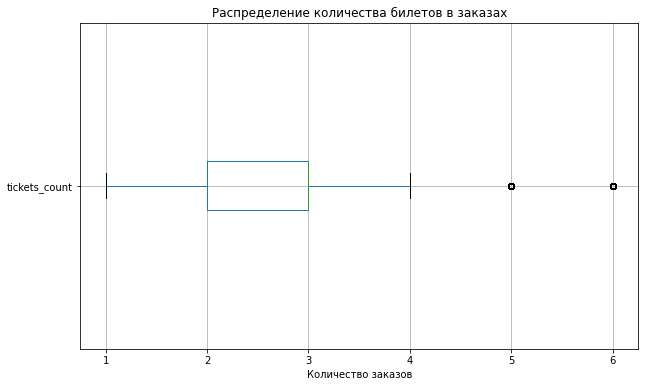

In [21]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества билетов в заказах')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

 - Теперь данные выглядят более аккуратными. Основной массив данных 1-4 билета. Медиана - 3 билета.
 
 - Судя по диаграмме размаха наблюдаются единичные выбросы в 5,6 билетов. Но удалять мы их не будем, так как заказы по 5,6 билетов могут быть.

Исследуем значения в столбце revenue. Изначально данные по выручке были представлены в разных валютах, поэтому разделим анализ на рубли и тенге:

In [22]:
# Создаем датафрейм для рублевых заказов
df_rub = df[df['currency_code'] == 'rub'].copy()

# Создаем датафрейм для тенговых заказов  
df_kzt = df[df['currency_code'] == 'kzt'].copy()

# Анализируем выручку в рублях
display("Выручка в рублях (RUB): ")
display(df_rub['revenue'].describe().round(2))

# Анализируем выручку в тенге
display("Выручка в тенге (KZT):")
display(df_kzt['revenue'].describe().round(2))

'Выручка в рублях (RUB): '

count    285354.00
mean        547.70
std         871.64
min         -90.76
25%         114.05
50%         346.45
75%         791.38
max       81174.54
Name: revenue, dtype: float64

'Выручка в тенге (KZT):'

count     5069.00
mean      4995.21
std       4916.75
min          0.00
25%        518.10
50%       3698.83
75%       7397.66
max      26425.86
Name: revenue, dtype: float64

**Анализ статистики выручки**


**Выручка в рублях (RUB)**


- Общее количество записей (count): 285354, что указывает на обширный объем данных.


- Среднее значение (mean): 547,70 RUB, отражающее типичный уровень выручки.


- Стандартное отклонение (std): 871,64 RUB, показывающее значительную вариабельность.


- Минимальное значение (min): -90,76 RUB, что может указывать на ошибки данных или возвраты.


- Квартили: 25% — 114,05 RUB, 50% (медиана) — 346,45 RUB, 75% — 791,38 RUB. Большая часть выручки сосредоточена ниже 791.38 RUB.


- Максимальное значение (max): 81174.54 RUB, что указывает на наличие редких, очень крупных транзакций.



**Выручка в тенге (KZT)**


- Общее количество записей (count): 5069, значительно меньше, чем для RUB.


- Среднее значение (mean): 4995,21 KZT.


- Стандартное отклонение (std): 4916,75 KZT, указывающее на высокую вариабельность.


- Минимальное значение (min): 0,00 KZT, что может быть связано с нулевыми транзакциями или ошибками.


- Квартили: 25% — 518,10 KZT, 50% (медиана) — 3698,83 KZT, 75% — 7397,66 KZT. Большая часть выручки лежит ниже 7397,66 KZT.


- Максимальное значение (max): 26425,86 KZT, что соответствует крупным транзакциям.


**Краткий вывод**

Выручка в рублях демонстрирует более низкое среднее значение (547.70 RUB) и более широкий разброс (до 81174.54 RUB), включая отрицательные значения, что требует проверки данных. Выручка в тенге выше в среднем (4995.21 KZT) с меньшим количеством записей и отсутствием отрицательных значений, но с заметной вариабельностью (до 26425.86 KZT). Обе валюты имеют редкие крупные транзакции, которые могут быть связаны с групповыми покупками или аномалиями. Для дополнительного анализа построим гистограммы распределения и диаграммы размаха.



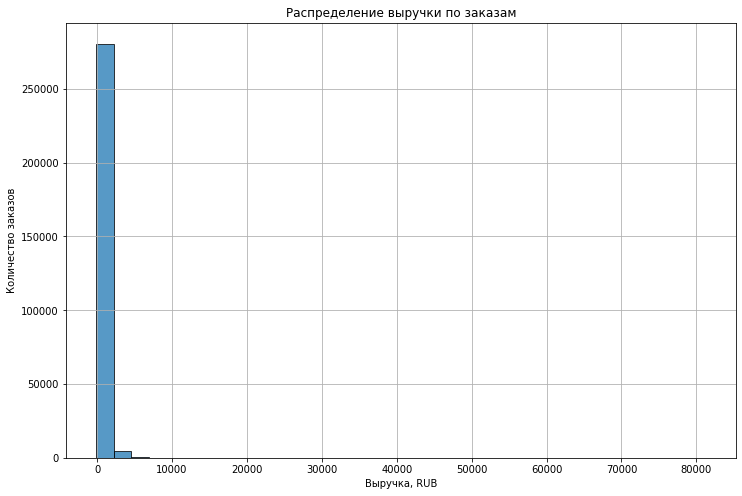

In [23]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 8))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_rub['revenue'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=35, # Устанавливаем количество корзин 
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение выручки по заказам')
plt.xlabel('Выручка, RUB')
plt.ylabel('Количество заказов')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Наблюдается ненормальное распределении с правосторонней асимметрией (смещено вправо из-за выбросов).Основная масса значений сосредоточена в интервале 0-2500.

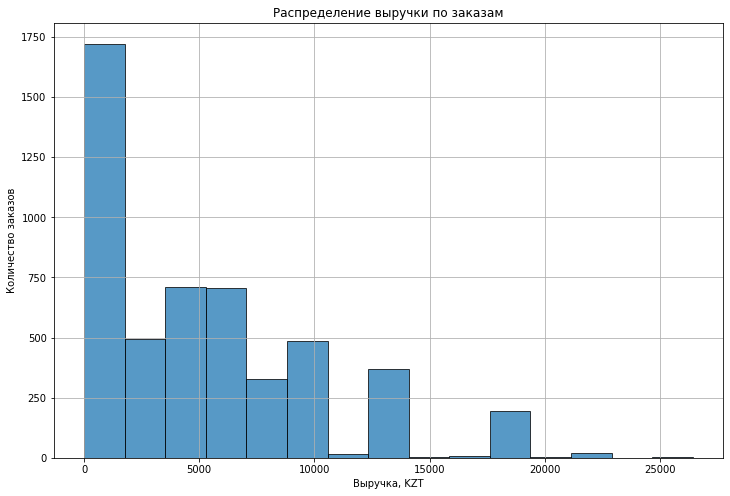

In [24]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 8))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_kzt['revenue'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=15, # Устанавливаем количество корзин 
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение выручки по заказам')
plt.xlabel('Выручка, KZT')
plt.ylabel('Количество заказов')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Наблюдается ненормальное распределении с правосторонней асимметрией (смещено вправо из-за выбросов).Основная масса значений сосредоточена в интервале 0-2000.

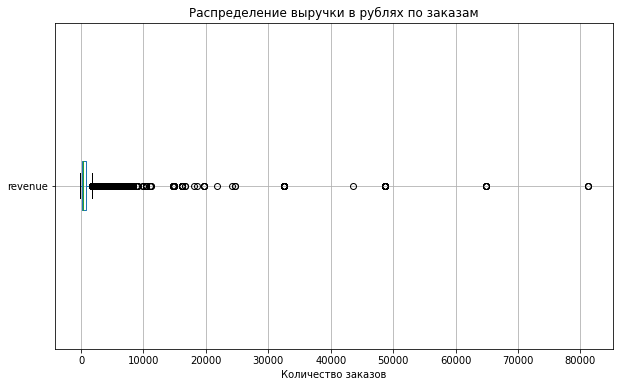

In [25]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df_rub.boxplot(column='revenue', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки в рублях по заказам')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

Анализ диаграммы позволяет выявить две ключевые особенности:

- Наличие выбросов: Значения, превышающие отметку в приблизительно 3000 RUB (верхний ус), являются аномальными и отображены точками.

- Правосторонняя асимметрия: Распределение выручки имеет длинный «хвост» в сторону высоких значений, вплоть до максимума в 81 174 RUB. Это говорит о том, что хотя большинство заказов невелики, редкие транзакции вносят непропорционально большой вклад в общую выручку.



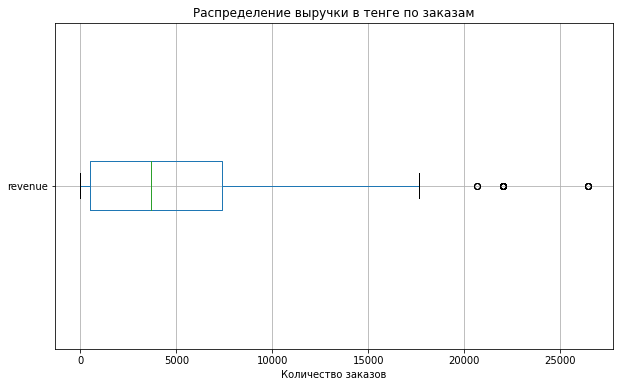

In [26]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df_kzt.boxplot(column='revenue', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки в тенге по заказам')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

- Нижний ус начинается с минимального значения  0, что может указывать на нулевые транзакции или ошибки данных. Верхний ус простирается примерно до 17000, определяя границу типичных значений.


- Значения выше верхнего уса (от примерно 17000 и до максимума 26426) представлены как отдельные точки. Это указывает на правостороннюю асимметрию, где редкие заказы с высокой выручкой значительно превышают типичные значения.


- Большая часть выручки сосредоточена в диапазоне 500 –7500.


Удалим заказы с отрицательной рублёвой выручкой:

In [27]:
# Создаем датафрейм для рублевых заказов с неотрицательной выручкой
df_rub_clear = df_rub[(df_rub['revenue'] >= 0)].copy()

# Подсчитываем количество исключенных строк
total_rub_orders = len(df_rub)
loss_rows = len(df_rub[(df_rub['revenue'] < 0)])
filtered_count = len(df_rub_clear)

# Рассчитываем процент потерь
loss_percentage = (loss_rows / total_rub_orders) * 100

display(f"Всего рублевых заказов: {total_rub_orders}")
display(f"Отфильтровано (отрицательная выручка): {loss_rows}")
display(f"Осталось после фильтрации: {filtered_count}")
display(f"Процент отфильтрованных данных: {loss_percentage:.2f}%")

'Всего рублевых заказов: 285354'

'Отфильтровано (отрицательная выручка): 381'

'Осталось после фильтрации: 284973'

'Процент отфильтрованных данных: 0.13%'

In [28]:
# Сохраняем исходный размер датафрейма
original_size = df_rub_clear.shape[0]

# Вычисляем пороговое значение 
threshold = df_rub_clear['revenue'].quantile(0.99)

# Удаляем строки с значениями выше порога
df_rub_clear = df_rub_clear[df_rub_clear['revenue'] <= threshold]

# Проверяем результат
new_size = df_rub_clear.shape[0]
removed_rows = original_size - new_size
removed_percentage1 = (removed_rows / original_size) * 100

# Выводим результат
display(f"Исходный размер датафрейма: {original_size}")
display(f"Новый размер датафрейма: {df_rub_clear.shape[0]}")
display(f"Количество удаленных строк: {removed_rows}")
display(f"Процент удаленных строк: {removed_percentage1:.2f}%")
display(f"Пороговое значение (99% перцентиль): {threshold:.2f}")

'Исходный размер датафрейма: 284973'

'Новый размер датафрейма: 282123'

'Количество удаленных строк: 2850'

'Процент удаленных строк: 1.00%'

'Пороговое значение (99% перцентиль): 2569.60'

In [29]:
# Сохраняем исходный размер датафрейма
original_size = df_kzt.shape[0]

# Вычисляем пороговое значение 
threshold = df_kzt['revenue'].quantile(0.99)

# Удаляем строки с значениями выше порога
df_kzt_clear = df_kzt[df_kzt['revenue'] <= threshold]

# Проверяем результат
new_size = df_kzt_clear.shape[0]
removed_rows = original_size - new_size
removed_percentage2 = (removed_rows / original_size) * 100

# Выводим результат
display(f"Исходный размер датафрейма: {original_size}")
display(f"Новый размер датафрейма: {new_size}")
display(f"Количество удаленных строк: {removed_rows}")
display(f"Процент удаленных строк: {removed_percentage2:.2f}%")
display(f"Пороговое значение (99% перцентиль): {threshold:.2f}")

'Исходный размер датафрейма: 5069'

'Новый размер датафрейма: 5040'

'Количество удаленных строк: 29'

'Процент удаленных строк: 0.57%'

'Пороговое значение (99% перцентиль): 17617.24'

Данные успешно очищены от выбросов.

После очистки данных от выбросов объединим два очищенных датафрейма в один:

In [30]:
# Объединяем обратно в один датафрейм
df_new = pd.concat([df_rub_clear, df_kzt_clear], ignore_index=True)

# Проверим результат
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287163 entries, 0 to 287162
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287163 non-null  int64         
 1   user_id                 287163 non-null  object        
 2   created_dt_msk          287163 non-null  datetime64[ns]
 3   created_ts_msk          287163 non-null  datetime64[ns]
 4   event_id                287163 non-null  int64         
 5   cinema_circuit          287163 non-null  object        
 6   age_limit               287163 non-null  int8          
 7   currency_code           287163 non-null  object        
 8   device_type_canonical   287163 non-null  object        
 9   revenue                 287163 non-null  float64       
 10  service_name            287163 non-null  object        
 11  tickets_count           287163 non-null  int8          
 12  total                   287163

Посчитаем суммарную долю удаленных данных по всем этапам очистки:

In [31]:
# Первоначальный размер датафреймфа до очистки
stat_size = df.shape[0]

# Pазмер датафреймфа после очистки
new_size = df_new.shape[0]

# Суммарная доля удаленных данных по всем этапам очистки
share_deleted_data = removed_percentage + loss_percentage + removed_percentage1 + removed_percentage2

# Выводим результат
display("Результаты очистки данных:")
display(f"Первоначальный размер датафрейма: {stat_size} строк")
display(f"Размер после очистки: {new_size} строк")
display(f"Количество удаленных строк: {stat_size - new_size}")
display(f"Суммарная доля удаленных данных: {share_deleted_data:.2f}%")

'Результаты очистки данных:'

'Первоначальный размер датафрейма: 290423 строк'

'Размер после очистки: 287163 строк'

'Количество удаленных строк: 3260'

'Суммарная доля удаленных данных: 1.77%'

Изучим категориальные данные. При помощи метода value_counts() изучим распределение данных по уникальным значениям в столбце:

In [32]:
# Проверка категориальных признаков
categories = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 
 'service_name', 'event_type_description', 'event_type_main', 'region_name', 'city_name']
for categ in categories:
    display(df[categ].value_counts())


нет           289025
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

16    78546
12    62454
0     61446
6     52139
18    35838
Name: age_limit, dtype: int64

rub    285354
kzt      5069
Name: currency_code, dtype: int64

mobile     232384
desktop     58039
Name: device_type_canonical, dtype: int64

Билеты без проблем        63386
Лови билет!               41120
Билеты в руки             40336
Мой билет                 34813
Облачко                   26642
Лучшие билеты             17765
Весь в билетах            16849
Прачечная                 10273
Край билетов               6199
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             498
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

концерт                   112034
событие                    58468
спектакль                  50579
шоу                        13626
спорт                      12826
мюзикл                      9911
спортивное мероприятие      9072
балет                       5998
выставка                    5876
цирковое шоу                5325
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
подарок                        4
снегурочка                     3
рок-мюзикл                     1
Name: event_type_description, dtype: int64

концерты    115261
театр        67300
другое       65730
спорт        21898
стендап      13393
выставки      4854
ёлки          1987
Name: event_type_main, dtype: int64

Каменевский регион          91025
Североярская область        43932
Широковская область         16452
Медовская область           13899
Озернинский край            10474
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

Глиногорск      89413
Озёрск          43793
Радужсвет       13709
Радужнополье     8739
Верховино        6579
                ...  
Яблоновец           1
Синеполинск         1
Глинополянск        1
Ягодинска           1
Дальнозелен         1
Name: city_name, Length: 352, dtype: int64

Выведем распределение долей:

In [33]:
# Проверка категориальных признаков
categories = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 
 'service_name', 'event_type_description', 'event_type_main', 'region_name', 'city_name']
for categ in categories:
    display(df[categ].value_counts(normalize=True))


нет           0.995186
Другое        0.004342
КиноСити      0.000420
Киномакс      0.000024
Москино       0.000024
ЦентрФильм    0.000003
Name: cinema_circuit, dtype: float64

16    0.270454
12    0.215045
0     0.211574
6     0.179528
18    0.123399
Name: age_limit, dtype: float64

rub    0.982546
kzt    0.017454
Name: currency_code, dtype: float64

mobile     0.800157
desktop    0.199843
Name: device_type_canonical, dtype: float64

Билеты без проблем        0.218254
Лови билет!               0.141587
Билеты в руки             0.138887
Мой билет                 0.119870
Облачко                   0.091735
Лучшие билеты             0.061169
Весь в билетах            0.058015
Прачечная                 0.035373
Край билетов              0.021345
Тебе билет!               0.018001
Яблоко                    0.017351
Дом культуры              0.015502
За билетом!               0.009865
Городской дом культуры    0.009410
Show_ticket               0.007575
Мир касс                  0.007462
Быстробилет               0.006897
Выступления.ру            0.005564
Восьмёрка                 0.003850
Crazy ticket!             0.002720
Росбилет                  0.001856
Шоу начинается!           0.001715
Быстрый кассир            0.001312
Радио ticket              0.001295
Телебилет                 0.001105
КарандашРУ                0.000458
Реестр                    0.000430
Билет по телефону         0.000293
Вперёд!             

концерт                   0.385761
событие                   0.201320
спектакль                 0.174156
шоу                       0.046918
спорт                     0.044163
мюзикл                    0.034126
спортивное мероприятие    0.031237
балет                     0.020653
выставка                  0.020233
цирковое шоу              0.018335
фестиваль                 0.014713
опера                     0.004524
ёлка                      0.003254
музыкальный спектакль     0.000482
кукольный спектакль       0.000045
экскурсия                 0.000028
оперетта                  0.000024
подарок                   0.000014
снегурочка                0.000010
рок-мюзикл                0.000003
Name: event_type_description, dtype: float64

концерты    0.396873
театр       0.231731
другое      0.226325
спорт       0.075400
стендап     0.046115
выставки    0.016714
ёлки        0.006842
Name: event_type_main, dtype: float64

Каменевский регион          0.313422
Североярская область        0.151269
Широковская область         0.056648
Медовская область           0.047858
Озернинский край            0.036065
                              ...   
Лесноярский край            0.000065
Крутоводский регион         0.000062
Верхозёрский край           0.000038
Сосноводолинская область    0.000034
Теплоозёрский округ         0.000024
Name: region_name, Length: 81, dtype: float64

Глиногорск      0.307872
Озёрск          0.150790
Радужсвет       0.047204
Радужнополье    0.030091
Верховино       0.022653
                  ...   
Яблоновец       0.000003
Синеполинск     0.000003
Глинополянск    0.000003
Ягодинска       0.000003
Дальнозелен     0.000003
Name: city_name, Length: 352, dtype: float64

**Анализ категориальных данных**

- cinema_circuit: Большинство записей (99,5%) — "нет", что указывает на преобладание событий вне кинотеатров; кинотеатры (КиноСити, Москино и др.) редки (<0,5%).

- age_limit: Основные возрастные ограничения — 16 (27%), 12 (22%), 0 (21%), 6 (18%), 18 (12%), что отражает разнообразие аудитории.

- currency_code: Преобладает рубль (98%), тенге - 2%.

- device_type_canonical: Мобильные устройства доминируют (80%), десктоп — 20%.

- service_name: Лидеры — "Билеты без проблем" (22%), "Лови билет!" (14%), "Билеты в руки" (14%), топ-3 покрывают 50% заказов.

- event_type_description: Концерты (39%) и события (20%) лидируют, следуют спектакли (18%) и шоу (5%), нишевые категории (оперетта, экскурсия) редки (<0,01%).

- event_type_main: Концерты (40%) и театр (23%) доминируют, "другое" (23%), спорт (8%), стендап (5%), выставки и ёлки (<2%) менее популярны.

- region_name: Каменевский регион (32%) и Североярская область (15%) лидируют, остальные регионы распределены неравномерно (до 0,01% для мелких).

- city_name: Глиногорск (31%) и Озёрск (15%) доминируют, мелкие города (<0,01%) редки.


<a id='якорь4'></a>
## 4. Проверка дубликатов.

Проверим объединенный датафрейм df_new на явные (полные) дубликаты:


In [34]:
# Проверка на полные дубликаты 
duplicates = df_new.duplicated().sum() 
display(f"Количество полных дубликатов: {duplicates}")

'Количество полных дубликатов: 0'

Проверим неявные дубликаты по всем столбцам кроме идентификаторов заказа, столбца order_id:

In [35]:
# Создаем пустой список
columns_to_check = []

# При помощи цикла проходим по всем колонкам датафрейма кроме 'order_id'
for col in df_new.columns:
    if col != 'order_id':
        columns_to_check.append(col)

# Поиск неявных дубликатов
duplicated_rows = df_new.duplicated(subset=columns_to_check, keep=False).sum()
print(f"Количество неявных дубликатов: {duplicated_rows}")


Количество неявных дубликатов: 58


Посмотрим, что это за дубликаты:


In [36]:
# Получаем булевый маску дубликатов
duplicate_mask = df_new.duplicated(subset=columns_to_check, keep=False)

# Фильтруем датафрейм по этой маске и сортируем
duplicated_df_sorted = df_new[duplicate_mask].sort_values(by=columns_to_check)

display("Все неявные дубликаты (отсортированные):")
display(duplicated_df_sorted)

'Все неявные дубликаты (отсортированные):'

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
178455,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
178456,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
247961,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036,1656,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
247964,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036,1656,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
150966,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76,3094,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
150971,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76,3094,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
233328,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21,2155,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
233332,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21,2155,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
45805,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
45808,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"


Получили дубликаты - пары заказов с одинаковыми параметрами. Все поля идентичны, кроме идентификатора заказа. Время заказа идентично вплоть до секунды. Так как один пользователь не может одновременно оформить два заказа, будем считать дубликаты технической ошибкой и удалим их.

In [37]:
# Удаляем дубликаты, оставляя первую запись в каждой группе
df_cleaned = df_new.drop_duplicates(subset=columns_to_check, keep='first')

# Рассчитываем потерю данных
original_size = len(df_new)
cleaned_size = len(df_cleaned)
removed_count = original_size - cleaned_size
deleted_percentage = (removed_count / original_size) * 100

display(f"Исходное количество записей: {original_size}")
display(f"Количество после очистки: {cleaned_size}")
display(f"Удалено дубликатов: {removed_count}")
display(f"Процент удаленных дубликатов: {deleted_percentage:.4f}%")

'Исходное количество записей: 287163'

'Количество после очистки: 287133'

'Удалено дубликатов: 30'

'Процент удаленных дубликатов: 0.0104%'

Проверим результат:

In [38]:
# Создаем пустой список
columns_to_check = []

# При помощи цикла проходим по всем колонкам датафрейма кроме 'order_id'
for col in df_cleaned.columns:
    if col != 'order_id':
        columns_to_check.append(col)

# Поиск неявных дубликатов
duplicated_rows = df_cleaned.duplicated(subset=columns_to_check, keep=False).sum()
print(f"Количество неявных дубликатов: {duplicated_rows}")


Количество неявных дубликатов: 0


Все неявные дубликаты были успешно удалены.

Посчитаем суммарную долю удаленных данных по всем этапам очистки, включая удаление дубликатов:

In [39]:
# Суммарная доля удаленных данных по всем этапам очистки
percent_deleted_data = share_deleted_data + deleted_percentage

# Выводим результат
display(f"Доля всех удаленных данных: {percent_deleted_data:.2f}%")


'Доля всех удаленных данных: 1.78%'

Для удобства переименуем очищеный датафрейм df_cleaned в df:

In [40]:
df = df_cleaned

# Выведем информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287133 entries, 0 to 287162
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287133 non-null  int64         
 1   user_id                 287133 non-null  object        
 2   created_dt_msk          287133 non-null  datetime64[ns]
 3   created_ts_msk          287133 non-null  datetime64[ns]
 4   event_id                287133 non-null  int64         
 5   cinema_circuit          287133 non-null  object        
 6   age_limit               287133 non-null  int8          
 7   currency_code           287133 non-null  object        
 8   device_type_canonical   287133 non-null  object        
 9   revenue                 287133 non-null  float64       
 10  service_name            287133 non-null  object        
 11  tickets_count           287133 non-null  int8          
 12  total                   287133

После удаления дубликатов индексы стали непоследовательными. Сбросим индексы:

In [41]:
# Сбрасываем индексы чтобы они стали последовательными
df = df.reset_index(drop=True)

# Выведем информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287133 entries, 0 to 287132
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287133 non-null  int64         
 1   user_id                 287133 non-null  object        
 2   created_dt_msk          287133 non-null  datetime64[ns]
 3   created_ts_msk          287133 non-null  datetime64[ns]
 4   event_id                287133 non-null  int64         
 5   cinema_circuit          287133 non-null  object        
 6   age_limit               287133 non-null  int8          
 7   currency_code           287133 non-null  object        
 8   device_type_canonical   287133 non-null  object        
 9   revenue                 287133 non-null  float64       
 10  service_name            287133 non-null  object        
 11  tickets_count           287133 non-null  int8          
 12  total                   287133

<a id='якорь5'></a>
## 5. Создание новых столбцов и подсчет основных метрик

Создадим новый столбец revenue_rub, где вся выручка будет в рублях. Для этого объединим датафрейм `df` c датафреймом `final_tickets_tenge_df.csv`(df_exchange), в котором хранится информация о курсе тенге к российскому рублю за 2024 год.


Подготовим датафрейм df_exchange к объединению:

In [42]:
# Переименуем столбцы для удобства
df_exchange = df_exchange.rename(columns={'data': 'date', 'curs': 'exchange_rate'})

# Рассчитаем курс для 1 тенге (в данных курс для 100 тенге)
df_exchange['exchange_rate'] = df_exchange['exchange_rate'] / 100

# Оставим только нужные столбцы
df_exchange = df_exchange[['date', 'exchange_rate']]

display(df_exchange.head())

,date,exchange_rate
0,2024-01-10,0.199391
1,2024-01-11,0.197255
2,2024-01-12,0.195839
3,2024-01-13,0.194501
4,2024-01-14,0.194501


Подготовим датафрейм df к объединению:

In [43]:
# Создаем столбец с датой для объединения
df['date'] = df['created_dt_msk'].dt.date

# Преобразуем в datetime64
df['date'] = pd.to_datetime(df['date'])

# Проверка типа данных
display(df['date'].dtype)


dtype('<M8[ns]')

In [44]:
# Объединяем датафрейм df с датафреймом df_exchange
df = pd.merge(df, df_exchange, on='date', how='left')

display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,date,exchange_rate
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419


In [45]:
# Создаем новый столбец с выручкой в рублях
df['revenue_rub'] = df['revenue']  

# Для тенговых заказов конвертируем по курсу
kzt_mask = df['currency_code'] == 'kzt'
df.loc[kzt_mask, 'revenue_rub'] = df.loc[kzt_mask, 'revenue'] * df.loc[kzt_mask, 'exchange_rate']

# Округляем до 2 знаков после запятой 
df['revenue_rub'] = df['revenue_rub'].round(2)

display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,date,exchange_rate,revenue_rub
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1141.45
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1521.94


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287133 entries, 0 to 287132
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287133 non-null  int64         
 1   user_id                 287133 non-null  object        
 2   created_dt_msk          287133 non-null  datetime64[ns]
 3   created_ts_msk          287133 non-null  datetime64[ns]
 4   event_id                287133 non-null  int64         
 5   cinema_circuit          287133 non-null  object        
 6   age_limit               287133 non-null  int8          
 7   currency_code           287133 non-null  object        
 8   device_type_canonical   287133 non-null  object        
 9   revenue                 287133 non-null  float64       
 10  service_name            287133 non-null  object        
 11  tickets_count           287133 non-null  int8          
 12  total                   287133

Столбец revenue_rub успешно создан.

In [47]:
# # Вычисляем стоимость одного билета для каждого заказа и создаем столбец one_ticket_revenue_rub
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count']).round(2)

# Создаем столбец month с номером месяца из даты заказа
df['month'] = df['created_dt_msk'].dt.month


display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_name,city_id,venue_id,venue_name,venue_address,date,exchange_rate,revenue_rub,one_ticket_revenue_rub,month
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94,380.48,8
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.48,7
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1141.45,380.48,7
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.48,7
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1521.94,380.48,7


При помощи метода pd.cut() столбец month разобьём на категории `лето`, `зима`, `весна`, `осень` и создадим новый столбец season:

In [48]:
# Определяем границы и метки для сезонов
bins = [0, 2, 5, 8, 11, 12]
labels = ['зима', 'весна', 'лето', 'осень', 'зима']

df['season'] = pd.cut(df['month'], bins=bins, labels=labels, ordered=False)

display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,date,exchange_rate,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94,380.48,8,лето
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.48,7,лето
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1141.45,380.48,7,лето
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.48,7,лето
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1521.94,380.48,7,лето


Столбец season успешно создан.

<a id='якорь6'></a>
## 6. Промежуточный вывод


В ходе анализа и обработки данных были выполнены следующие основные действия:

- Загрузка и первичный анализ данных: Загружены три датасета — `final_tickets_orders_df.csv` (заказы билетов), `final_tickets_events_df.csv` (события) и `final_tickets_tenge_df.csv` (курсы валют). 

- Проведена оценка типов данных и выявлены пропуски (7,5% в столбце days_since_prev в orders,  остальные столбцы без пропусков).


- Оптимизация типов данных: Преобразованы столбцы created_dt_msk и created_ts_msk в datetime64, data в df_exchange в datetime64. 


- Размерность столбцов age_limit, tickets_count и nominal снижена с int64 до int8 для оптимизации памяти.


- Объединение датафреймов: Выполнено объединение orders и events по event_id с использованием INNER JOIN, что уменьшило количество записей до 290611. Пропуски в days_since_prev оставлены без изменений, так как они связаны с отсутствием предыдущих покупок.


- Исследовательский анализ и очистка выбросов:

- Для tickets_count: Удалены значения выше 99%-го процентиля (6 билетов), что составило 0,06% данных.


- Для revenue: Удалены отрицательные значения в рублях (0,13%) и значения выше 99%-го процентиля (2569,60 RUB для рублевых заказов и 17617,24 KZT для тенговых), что составило 1,00% и 0,57% соответственно. Общая доля удаленных данных — 1,77%.


- Удалены неявные дубликаты (30 записей, 0,0104%), связанные с техническими ошибками, что довело суммарную долю удаленных данных до 1,78%.


- Создание новых столбцов:

- revenue_rub: Выручка приведена к единой валюте (RUB) с использованием курсов тенге из df_exchange. Для тенговых заказов выручка конвертируется по актуальному курсу на дату заказа, округляется до 2 знаков.


- one_ticket_revenue_rub: Средняя выручка с одного билета для каждого заказа, рассчитанная как отношение выручки в рублях к количеству билетов в заказе (округлена до 2 знаков).


- month: Извлечен номер месяца из даты заказа (created_dt_msk).


- season: Создана категория сезонности ('зима', 'весна', 'лето', 'осень') на основе месяца с использованием интервалов: 0–2 (зима), 3–5 (весна), 6–8 (лето), 9–11 (осень), 12 (зима).


- Описание новых столбцов:

- revenue_rub: Обеспечивает единый формат выручки в рублях, что упрощает дальнейший анализ и сравнение.

- one_ticket_revenue_rub: Позволяет оценить среднюю доходность с каждого билета, полезно для анализа рентабельности.

- month: Упрощает временной анализ заказов по месяцам.

- season: Облегчает изучение сезонных тенденций в покупках билетов.


<a id='якорь7'></a>
## 7. Исследовательский анализ данных


На стадии исследовательского анализа изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью. 

Проанализируем динамику по таким разрезам:

- тип мероприятия event_type_main;

- тип устройства device_type_canonical;

- категория мероприятий по возрастному рейтингу age_limit.
 

### 7.1 Анализ распределения заказов по сегментам и их сезонные изменения

Изучим распределение заказов по сегментам и их сезонные изменения, выполнив следующие шаги:

- Для каждого месяца найдем количество заказов и визуализируем результаты. Проверим, фиксируется ли увеличение заказов от июня к ноябрю 2024 года.



- Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Результаты визуализируем подходящим графиком, который поможет сопоставить значения для летнего и осеннего сезонов.



- Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. Видна ли динамика средней стоимости билета в разрезе разных категорий мероприятий? Для каждого типа мероприятия рассчитаем среднее значение выручки с одного билета, затем найдём относительное изменение осенних значений по сравнению с летними. Результат сопроводим подходящей визуализацией.



Для каждого месяца найдем количество заказов:

In [49]:
# Количество заказов по месяцам
count_orders = df.groupby('month')['order_id'].count()

# Выводим результат
display("Количество заказов по месяцам:")
display(count_orders)

'Количество заказов по месяцам:'

month
6     34039
7     40329
8     44488
9     69194
10    99083
Name: order_id, dtype: int64

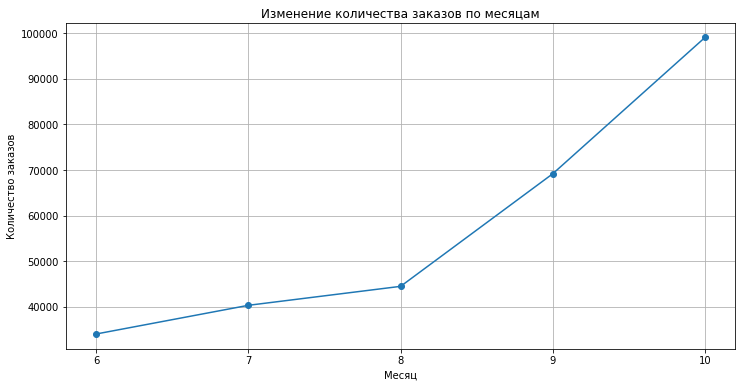

In [50]:
# Преобразуем месяцы в целые числа
count_orders.index = count_orders.index.astype(int)

# Строим  линейный график 
plt.figure(figsize=(12, 6))
count_orders.plot(
    kind='line',
    marker='o',
    title='Изменение количества заказов по месяцам',
    xlabel='Месяц',
    ylabel='Количество заказов',
    grid=True
)
# Задаем целочисленные деления на оси X
plt.xticks(count_orders.index)

plt.show()

Наблюдается рост количества заказов от июня к ноябрю 2024 г, а следовательно и возросла пользовательская активность.

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу

In [51]:
# Фильтруем данные по летнему и осеннему сезонам
df_summer = df[df['season'] == 'лето']
df_autumn = df[df['season'] == 'осень']

# Считаем в абсолютных значениях
summer_abs = df_summer['event_type_main'].value_counts()
autumn_abs = df_autumn['event_type_main'].value_counts()


# Считаем долю заказов по типу мероприятия (event_type_main)
summer_event = df_summer['event_type_main'].value_counts(normalize=True).round(2)
autumn_event = df_autumn['event_type_main'].value_counts(normalize=True).round(2)

# Выводим результат
display('Количество заказов по типу мероприятия в летний период:')
display(summer_abs)
display('Количество заказов по типу мероприятия в осенний период:')
display(autumn_abs)
display('Доля заказов по типу мероприятия в летний период:')
display(summer_event)
display('Доля заказов по типу мероприятия в осенний период:')
display(autumn_event)


'Количество заказов по типу мероприятия в летний период:'

концерты    50753
другое      32141
театр       23935
стендап      6346
спорт        3001
выставки     2407
ёлки          273
Name: event_type_main, dtype: int64

'Количество заказов по типу мероприятия в осенний период:'

концерты    62683
театр       42728
другое      33001
спорт       18851
стендап      6923
выставки     2402
ёлки         1689
Name: event_type_main, dtype: int64

'Доля заказов по типу мероприятия в летний период:'

концерты    0.43
другое      0.27
театр       0.20
стендап     0.05
спорт       0.03
выставки    0.02
ёлки        0.00
Name: event_type_main, dtype: float64

'Доля заказов по типу мероприятия в осенний период:'

концерты    0.37
театр       0.25
другое      0.20
спорт       0.11
стендап     0.04
выставки    0.01
ёлки        0.01
Name: event_type_main, dtype: float64

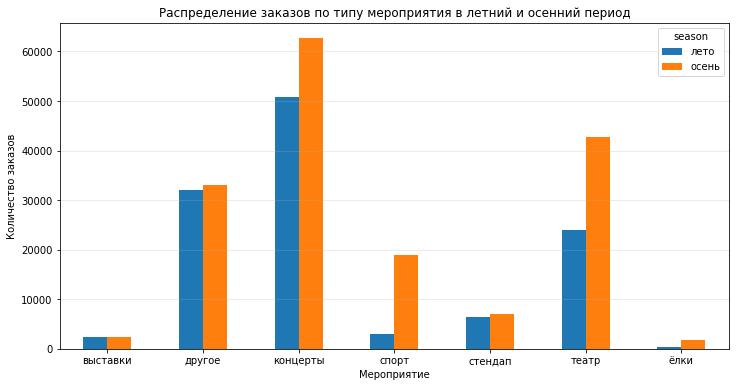

In [52]:
# Построим график столбчатой диаграммы
grouped = df.groupby('event_type_main')['season'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение заказов по типу мероприятия в летний и осенний период',
               legend=True,
               ylabel='Количество заказов',
               xlabel='Мероприятие',
               rot=0,
               figsize=(12, 6))
plt.grid(axis='y', alpha=0.3)

# Выводим график
plt.show() 

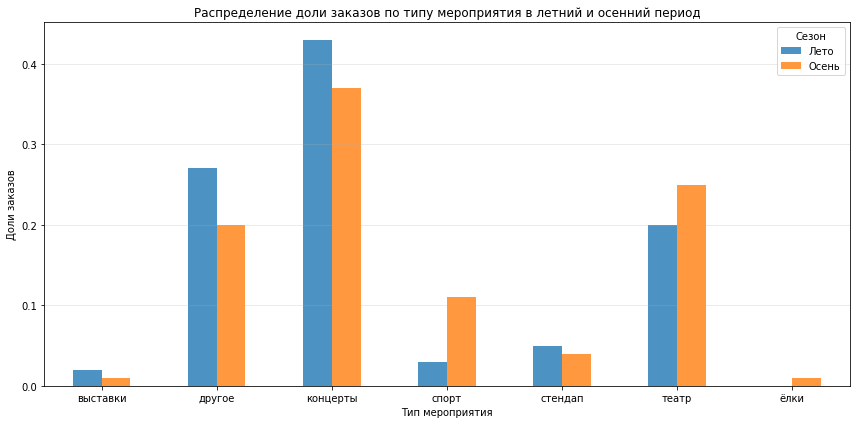

In [53]:
# Создаем датафрейм с долями для графика
df_share = pd.DataFrame({
    'Лето': summer_event,
    'Осень': autumn_event
})

# Строим график столбчатой диаграммы для долей
df_share.plot(kind='bar',
               title='Распределение доли заказов по типу мероприятия в летний и осенний период',
               legend=True,
               ylabel='Доли заказов',
               xlabel='Тип мероприятия',
               rot=0,
               figsize=(12, 6),
               alpha=0.8)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

**Анализ распределения заказов по типу мероприятий в летний и осенний сезоны**

Распределение заказов в летний сезон:

- В летний период (июнь–август) преобладают концерты, составляющие 43% всех заказов, что делает их доминирующей категорией.

- На втором месте — "другое" (27%).

- Театр занимает 20%.

- Менее популярны стендап (5%), спорт (3%) и выставки (2%), что отражает снижение спроса в теплый период.


- Ёлки практически отсутствуют (0%), что логично, так как это новогодняя тематика.

Распределение заказов в осенний сезон:

- В осенний период (сентябрь–ноябрь) концерты остаются лидерами, но их доля снижается до 37%, что все равно делает их основной категорией.

- Театр набирает популярность (25%), возможно, из-за начала театрального сезона.

- "Другое" составляет 20%, доля немного снизилась по сравнению с летним периодом.

- Спорт — 11%, рост по сравнению с летом, вероятно, из-за начала спортивных сезонов, таких как футбол или хоккей.

- Стендап (4%) и выставки (1%) остаются нишевыми.

- Появляются ёлки (1%), что может быть связано с подготовкой к новогодним праздникам в ноябре.

Сравнение летнего и осеннего сезонов

Общие тенденции: В обоих сезонах концерты доминируют (43% летом vs. 37% осенью), но их доля снижается осенью, в то время как абсолютное количество растет с 50753 до 62683, что указывает на общий рост заказов в осень. Театр показывает обратную динамику: рост доли с 20% до 25% и абсолютных значений с 23935 до 42728, что подчеркивает сезонный сдвиг к классике. "Другое" теряет долю (с 27% до 20%), но остается значимым, с ростом абсолютных заказов (32141 до 33001).
Различия в нишевых категориях: Спорт значительно растет осенью (с 3% (3001) до 11% (18851), вероятно, из-за старта лиг и турниров. Стендап слегка снижается (5% до 4%), но остается значимым, с ростом абсолютных заказов (6346 до 6923).

**Вывод**

Несмотря на снижение осенью относительных долей некоторых мероприятий, общее количество заказов растет, что свидетельствует об увеличении общей активности аудитории в осенний период.

In [54]:
# Считаем в абсолютных значениях
summer_abs_count = df_summer['device_type_canonical'].value_counts()
autumn_abs_count = df_autumn['device_type_canonical'].value_counts()


# Считаем долю заказов по типу устройства (device_type_canonical)
summer_share = df_summer['device_type_canonical'].value_counts(normalize=True).round(2)
autumn_share = df_autumn['device_type_canonical'].value_counts(normalize=True).round(2)

# Выводим результат
display('Количество заказов по типу устройства в летний период:')
display(summer_abs_count)
display('Количество заказов по типу устройства в осенний период:')
display(autumn_abs_count)
display('Доля заказов по типу устройства в летний период:')
display(summer_share)
display('Доля заказов по типу устройства в осенний период:')
display(autumn_share)

'Количество заказов по типу устройства в летний период:'

mobile     95840
desktop    23016
Name: device_type_canonical, dtype: int64

'Количество заказов по типу устройства в осенний период:'

mobile     134036
desktop     34241
Name: device_type_canonical, dtype: int64

'Доля заказов по типу устройства в летний период:'

mobile     0.81
desktop    0.19
Name: device_type_canonical, dtype: float64

'Доля заказов по типу устройства в осенний период:'

mobile     0.8
desktop    0.2
Name: device_type_canonical, dtype: float64

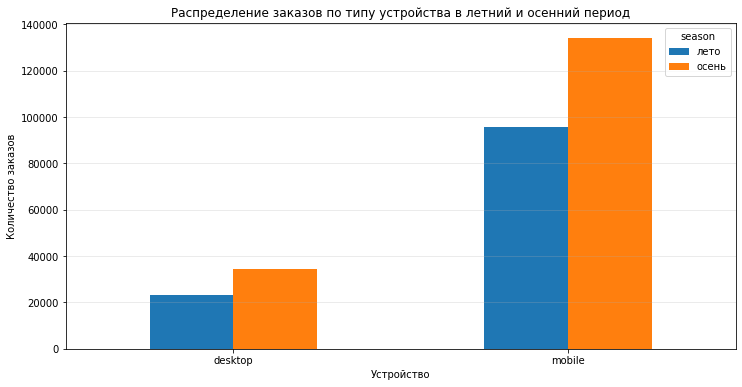

In [55]:
# Построим график столбчатой диаграммы
grouped = df.groupby('device_type_canonical')['season'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение заказов по типу устройства в летний и осенний период',
               legend=True,
               ylabel='Количество заказов',
               xlabel='Устройство',
               rot=0,
               figsize=(12, 6))
plt.grid(axis='y', alpha=0.3)

# Выводим график
plt.show() 

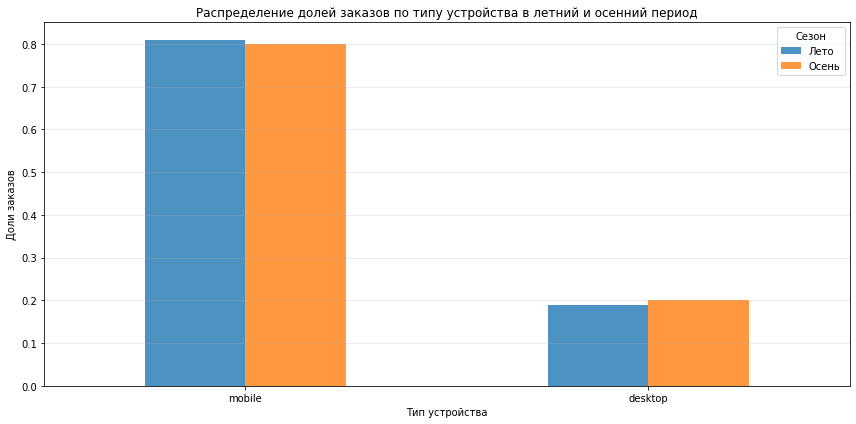

In [56]:
# Создаем датафрейм с долями для графика
df_share = pd.DataFrame({
    'Лето': summer_share,
    'Осень': autumn_share
})  

# Строим график столбчатой диаграммы для долей
df_share.plot(kind='bar',
               title='Распределение долей заказов по типу устройства в летний и осенний период',
               legend=True,
               ylabel='Доли заказов',
               xlabel='Тип устройства',
               rot=0,
               figsize=(12, 6),
               alpha=0.8)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

**Анализ распределения заказов по типу устройств в летний и осенний сезоны.**


Распределение заказов по устройствам


- Летний сезон: Мобильные устройства доминируют с 81% всех заказов (95 840 заказов), в то время как десктопы составляют лишь 19% (23 016 заказов). Это свидетельствует о выраженной мобильной ориентации пользователей в теплый период.


- Осенний сезон: Сохраняется аналогичное распределение - мобильные устройства занимают 80% заказов (134 036 заказов), десктопы - 20% (34 241 заказ). Относительные доли остаются стабильными.

Сравнение летнего и осеннего сезонов


- Распределение по типам устройств демонстрирует высокую стабильность между сезонами. Разница в долях составляет всего 1 % для мобильных устройств.


- Абсолютный рост: При сохранении пропорций наблюдается значительный рост абсолютных показателей: количество заказов с мобильных устройств увеличивается с 95 840 до 134 036 (рост на 38 196 заказов), с десктопов - с 23 016 до 34 241 (рост на 11 225 заказов). 


**Вывод:**
Наблюдается общий рост активности пользователей осенью без изменения их устройственных предпочтений.

In [57]:
# Считаем в абсолютных значениях
summer_abs_count = df_summer['age_limit'].value_counts()
autumn_abs_count = df_autumn['age_limit'].value_counts()


# Считаем долю заказов по типу устройства (device_type_canonical)
summer_share = df_summer['age_limit'].value_counts(normalize=True).round(2)
autumn_share = df_autumn['age_limit'].value_counts(normalize=True).round(2)

# Выводим результат
display('Количество заказов по категориям мероприятия по возрастному рейтингу в летний период:')
display(summer_abs_count)
display('Количество заказов по категориям мероприятия по возрастному рейтингу в осенний период:')
display(autumn_abs_count)
display('Доля заказов по категориям мероприятия по возрастному рейтингу в летний период:')
display(summer_share)
display('Доля заказов по категориям мероприятия по возрастному рейтингу в осенний период:')
display(autumn_share)


'Количество заказов по категориям мероприятия по возрастному рейтингу в летний период:'

16    33747
12    24418
6     21663
0     21255
18    17773
Name: age_limit, dtype: int64

'Количество заказов по категориям мероприятия по возрастному рейтингу в осенний период:'

16    44210
0     39686
12    37202
6     29656
18    17523
Name: age_limit, dtype: int64

'Доля заказов по категориям мероприятия по возрастному рейтингу в летний период:'

16    0.28
12    0.21
6     0.18
0     0.18
18    0.15
Name: age_limit, dtype: float64

'Доля заказов по категориям мероприятия по возрастному рейтингу в осенний период:'

16    0.26
0     0.24
12    0.22
6     0.18
18    0.10
Name: age_limit, dtype: float64

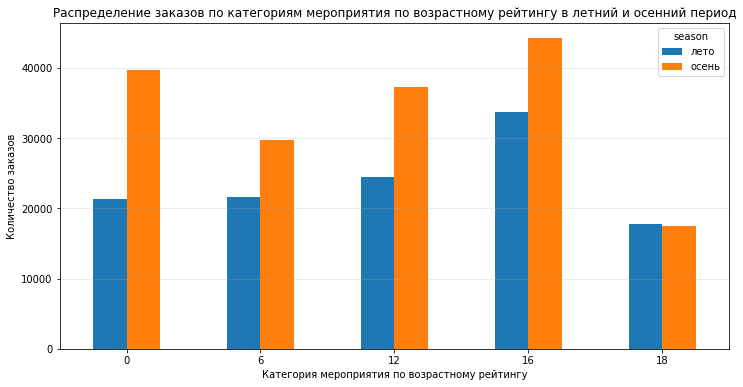

In [58]:
# Построим график столбчатой диаграммы
grouped = df.groupby('age_limit')['season'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение заказов по категориям мероприятия по возрастному рейтингу в летний и осенний период',
               legend=True,
               ylabel='Количество заказов',
               xlabel='Категория мероприятия по возрастному рейтингу',
               rot=0,
               figsize=(12, 6))
plt.grid(axis='y', alpha=0.3)

# Выводим график
plt.show() 

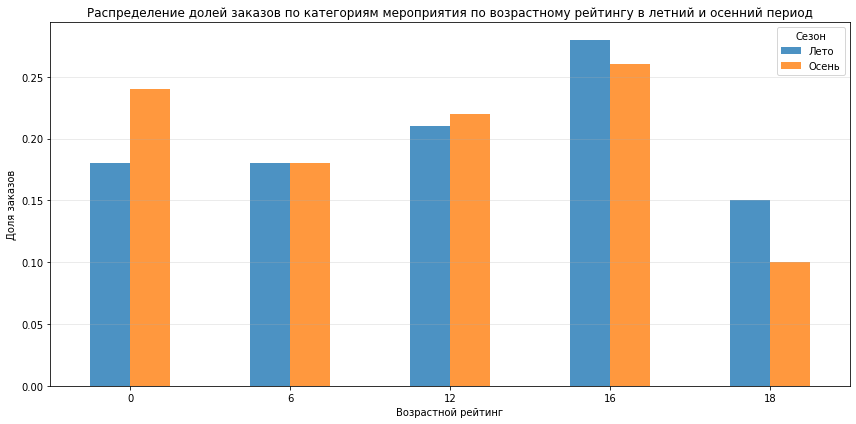

In [59]:
# Создаем датафрейм с долями для графика
df_share = pd.DataFrame({
    'Лето': summer_share,
    'Осень': autumn_share
})

# Сортируем по возрастному рейтингу (по возрастанию)
df_share = df_share.sort_index()

# Строим график столбчатой диаграммы для долей
df_share.plot(kind='bar',
               title='Распределение долей заказов по категориям мероприятия по возрастному рейтингу в летний и осенний период',
               legend=True,
               ylabel='Доля заказов',
               xlabel='Возрастной рейтинг',
               rot=0,
               figsize=(12, 6),
               alpha=0.8)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

**Анализ распределения заказов по категориям мероприятия по возрастному рейтингу в летний и осенний сезоны.**


Распределение заказов по возрастному рейтингу в летний сезон.


- В летний период (июнь–август) возрастной рейтинг 16 доминирует с 28% всех заказов (33 747 заказов), что указывает на высокую популярность мероприятий для подростков и взрослых.


- Рейтинг 12 занимает 21% (24 418 заказов). 


- Pейтинги 6 и 0 — по 18% (21 663 и 21 255 заказов соответственно), демонстрируя равномерный интерес к семейным и детским мероприятиям.


- Рейтинг 18 составляет 15% (17 773 заказов), что отражает меньший спрос на ограниченные по возрасту события. 


Распределение заказов по возрастному рейтингу в осенний сезон


- В осенний период (сентябрь–ноябрь) рейтинг 16 остается лидером с 26% заказов (44 210 заказов), сохраняя популярность среди подростков и взрослых. 


- Рейтинг 0 растет до 24% (39 686 заказов), вероятно, из-за сезонного интереса к семейным событиям. 

- Рейтинг 12 составляет 22% (37 202 заказов)  

- Pейтинг 6 — 18% (29 656 заказов), показывая стабильный спрос. 

- Рейтинг 18 снижается до 10% (17 523 заказов), что может указывать на меньшую активность в этой категории. 


Сравнение летнего и осеннего сезонов


Распределение по возрастным рейтингам демонстрирует высокую стабильность между сезонами. Разница в долях минимальна: рейтинг 16 снижается с 28% до 26%, 12 растет с 21% до 22%, 6 стабилен на 18%, 0 увеличивается с 18% до 24%, а 18 падает с 15% до 10%. Абсолютный рост значительный: заказы с рейтингом 16 увеличиваются с 33 747 до 44 210, 0 — с 21 255 до 39 686, 12 — с 24 418 до 37 202, 6 — с 21 663 до 29 656, 18 — с 17 773 до 17 523. График подчеркивает общий подъем заказов осенью, особенно для рейтингов 0 и 12, что может быть связано с началом учебного года и семейными мероприятиями. 


**Вывод:** 
Наблюдается общий рост активности пользователей осенью без значительных изменений в предпочтениях по возрастным рейтингам, с акцентом на семейные категории (0 и 12).



In [60]:
# Рассчитываем среднюю выручку с билета для каждого сезона отдельно
summer_revenue = df_summer.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_revenue = df_autumn.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

revenue_comparison = pd.DataFrame({
    'лето': summer_revenue,
    'осень': autumn_revenue,
    'изменение_руб': autumn_revenue - summer_revenue,
    'изменение_%': ((autumn_revenue - summer_revenue) / summer_revenue * 100).round(1)
}).round(2).sort_values('изменение_руб', ascending=False)

display(revenue_comparison)

,лето,осень,изменение_руб,изменение_%
event_type_main,,,,
стендап,218.52,231.12,12.61,5.8
выставки,86.74,91.90,5.16,5.9
спорт,50.80,50.04,-0.76,-1.5
другое,77.78,76.42,-1.36,-1.8
концерты,304.73,268.11,-36.62,-12.0
театр,214.17,175.98,-38.18,-17.8
ёлки,271.44,229.56,-41.87,-15.4


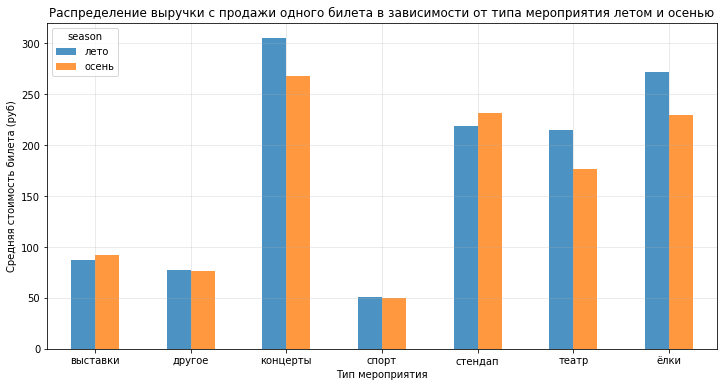

In [61]:
# Группируем по возрастному рейтингу и сезону, считаем среднюю стоимость билета
grouped_revenue = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack(fill_value=0)


grouped_revenue_filtered = grouped_revenue[['лето', 'осень']]


# Строим график
ax = grouped_revenue_filtered.plot(kind='bar',
               title='Распределение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью',
               legend=True,
               ylabel='Средняя стоимость билета (руб)',
               xlabel='Тип мероприятия',
               rot=0,
               figsize=(12, 6),
               alpha=0.8)

plt.grid(alpha=0.3)

# Выводим график
plt.show() 

Для большей наглядности относительного изменения осенних значений по сравнению с летними построим линейную диаграмму:

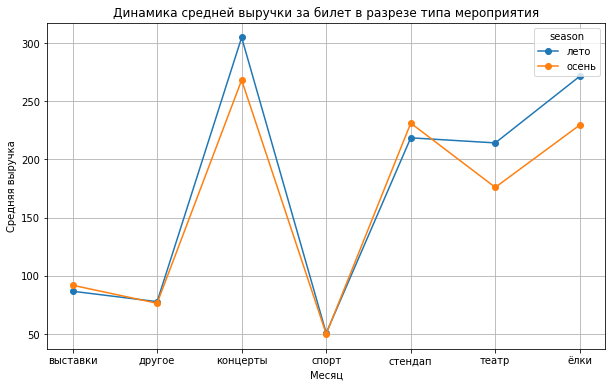

In [62]:
grouped_revenue_filtered.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Динамика средней выручки за билет в разрезе типа мероприятия')
plt.xlabel('Месяц')
plt.ylabel('Средняя выручка')
plt.grid(True)
plt.show()

**Анализ средней выручки за билет в летний и осенний сезоны по типам мероприятий.**

Распределение средней выручки в летний сезон:


- В летний период (июнь–август) наибольшая средняя выручка за билет наблюдается на концертах (304,73 руб.), что делает их самой прибыльной категорией, вероятно, благодаря высоким ценам на фестивали и open-air события. Ёлки следуют с 271,44 руб., стендап — 218,52 руб., театр — 214,17 руб., выставки — 86,74 руб., "другое" — 77,78 руб., а спорт замыкает список с минимальными 50,80 руб. 


Распределение средней выручки в осенний сезон:


- В осенний период (сентябрь–ноябрь) концерты сохраняют лидерство, но выручка снижается до 268,11 руб., что все равно делает их топ-категорией. Ёлки падают до 229,56 руб., стендап растет до 231,12 руб., театр снижается до 175,98 руб., выставки — до 91,90 руб., "другое" — до 76,42 руб., спорт — до 50,04 руб. 

Сравнение летнего и осеннего сезонов:


- Положительный рост наблюдается для стендапа (+12,61 руб., +5,8%) и выставок (+5,16 руб., +5,9%). Спорт (-0,76 руб., -1,5%) и "другое" (-1,36 руб., -1,8%) показывают минимальное снижение, сохраняя стабильность. Значительное падение фиксируется для концертов (-36,62 руб., -12%), театра (-38,18 руб., -17,8%) и ёлок (-41,87 руб., -15,4%), вероятно, из-за окончания фестивального сезона и перехода к более доступным осенним мероприятиям. 

**Вывод**

Средняя выручка за билет снижается осенью для большинства категорий (концерты, театр, ёлки), с общим падением на 12–18%, за исключением роста для стендапа и выставок (+5–6%). Это указывает на сезонный сдвиг к более доступным мероприятиям осенью. 



###   Промежуточный вывод.


- С наступлением осени (сентябрь–ноябрь 2024 года) наблюдается общий рост количества заказов по сравнению с летом (июнь–август 2024 года), что отражает увеличение пользовательской активности. Этот тренд сохраняется независимо от изменений в предпочтениях аудитории, включая стабильное доминирование мобильных устройств и незначительные сдвиги в возрастных рейтингах, с акцентом на семейные категории (0 и 12). Однако распределение заказов по типам мероприятий и средняя стоимость билета демонстрируют заметные изменения.


**Изменение распределения заказов по категориям**


**Концерты:** Доля заказов снижается с 43% летом до 37% осенью, но абсолютное количество растет (с 50753 до 62683), что связано с общим ростом активности. Концерты остаются лидером, но их относительная популярность уменьшается.


**Театр:** Доля увеличивается с 20% до 25%, а абсолютные заказы растут с 23935 до 42728, указывая на рост интереса к театральным постановкам осенью, вероятно, из-за начала сезона.


**"Другое":** Доля падает с 27% до 20%, но количество заказов увеличивается с 32141 до 33001, сохраняя значимость категории.


**Спорт:** Доля растет с 3% до 11%, а заказы увеличиваются с 3001 до 18851, что связано с началом спортивных сезонов.


**Стендап:** Доля слегка снижается с 5% до 4%, но остается значимым, с ростом абсолютных заказов с 6346 до 6923, показывая устойчивый интерес.


**Выставки:** Доля остается низкой (с 2% до 1%), но заказы остаются стабильны с 2407 до 2403, сохраняя минимальную активность.


**Ёлки:** Появляются осенью с 1% (1689 заказов), отсутствуя летом, что связано с подготовкой к новогоднему периоду.

Общий рост количества заказов с мобильных устройств увеличивается с 95 840 до 134 036 (рост на 38 196 заказов), с десктопов - с 23 016 до 34 241 (рост на 11 225 заказов).

**Изменение средней стоимости одного билета.**


Средняя выручка за билет демонстрирует разнонаправленную динамику:

**Концерты:** Снижение с 304,73 руб. до 268,11 руб. (-12%), что может быть связано с завершением фестивалей и переходом к менее дорогим мероприятиям.


**Театр:** Значительное падение с 214,17 руб. до 175,98 руб. (-17,8%), вероятно, из-за доступных постановок осенью.


**Ёлки:** Снижение с 271,44 руб. до 229,56 руб. (-15,4%), что отражает снижение цен на предновогодние события.


**Стендап:** Рост с 218,52 руб. до 231,12 руб. (+5,8%), указывая на рост популярности и цен на комедийные шоу.


**Выставки:** Небольшой рост с 86,74 руб. до 91,90 руб. (+5,9%), что может быть связано с сезонным спросом.


**Спорт:** Минимальное снижение с 50,80 руб. до 50,04 руб. (-1,5%), сохраняя стабильность.


**"Другое":** Незначительное падение с 77,78 руб. до 76,42 руб. (-1,8%), без значительных изменений.


**Общий вывод**

С наступлением осени распределение заказов смещается в сторону театральных, спортивных и семейных мероприятий (рейтинги 0 и 12), несмотря на снижение доли концертов. Абсолютный рост заказов во всех категориях подтверждает общий подъем активности. Средняя стоимость билета снижается для большинства категорий (концерты, театр, ёлки) на 12–18%, что указывает на сезонный сдвиг к более доступным ценам. Исключение составляют стендап и выставки, где выручка растет на 5–6%, отражая нишевый спрос. Стоит пересмотреть цены: сделать их более гибкими для популярных мероприятий и активнее продвигать категории, которые лучше продаются осенью. 

 

In [63]:
df_autumn.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 168277 entries, 14 to 287132
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                168277 non-null  int64         
 1   user_id                 168277 non-null  object        
 2   created_dt_msk          168277 non-null  datetime64[ns]
 3   created_ts_msk          168277 non-null  datetime64[ns]
 4   event_id                168277 non-null  int64         
 5   cinema_circuit          168277 non-null  object        
 6   age_limit               168277 non-null  int8          
 7   currency_code           168277 non-null  object        
 8   device_type_canonical   168277 non-null  object        
 9   revenue                 168277 non-null  float64       
 10  service_name            168277 non-null  object        
 11  tickets_count           168277 non-null  int8          
 12  total                   16827

### 7.2 Осенняя активность пользователей

Изучим активность пользователей осенью 2024 года.Работать будем с отфильтрованным по осенним месяцам датафреймом `df_autumn`.

Проанализируем динамику изменений по дням для:

- общего числа заказов;


- количества активных пользователей DAU;


- среднего числа заказов на одного пользователя;


- средней стоимости одного билета.

При помощи метода .pivot_table() cоздадим сводную таблицу с ежедневной статистикой:


In [64]:
# Создаем сводную таблицу с ежедневной статистикой
data = df_autumn.pivot_table(
    index=df_autumn['created_dt_msk'].dt.date, 
    values=['order_id', 'user_id', 'one_ticket_revenue_rub'],
    aggfunc={
        'order_id': 'count',           # Количество заказов
        'user_id': 'nunique',          # Уникальные пользователи (DAU)
        'one_ticket_revenue_rub': 'mean'}  # Средняя стоимость билета
    
).reset_index()

# Выведем первые пять строк таблицы
display(data.head())

,created_dt_msk,one_ticket_revenue_rub,order_id,user_id
0,2024-09-01,200.168885,1327,564
1,2024-09-02,190.015741,1376,573
2,2024-09-03,80.429385,5092,777
3,2024-09-04,179.130205,1758,682
4,2024-09-05,190.058198,1937,738


In [65]:
# Округляем стоимость билета до 2 знаков после запятой
data['one_ticket_revenue_rub'] = data['one_ticket_revenue_rub'].round()


# Переименуем колонки
data.columns = ['date', 'avg_ticket_price', 'total_orders', 'DAU']

# Выведем первые пять строк таблицы
display(data.head())

,date,avg_ticket_price,total_orders,DAU
0,2024-09-01,200.0,1327,564
1,2024-09-02,190.0,1376,573
2,2024-09-03,80.0,5092,777
3,2024-09-04,179.0,1758,682
4,2024-09-05,190.0,1937,738


In [66]:
# Рассчитываем среднее число заказов на пользователя
data['orders_per_user'] = (data['total_orders'] / data['DAU']).round(2)


# Выведем первые пять строк таблицы
display(data.head())

,date,avg_ticket_price,total_orders,DAU,orders_per_user
0,2024-09-01,200.0,1327,564,2.35
1,2024-09-02,190.0,1376,573,2.40
2,2024-09-03,80.0,5092,777,6.55
3,2024-09-04,179.0,1758,682,2.58
4,2024-09-05,190.0,1937,738,2.62


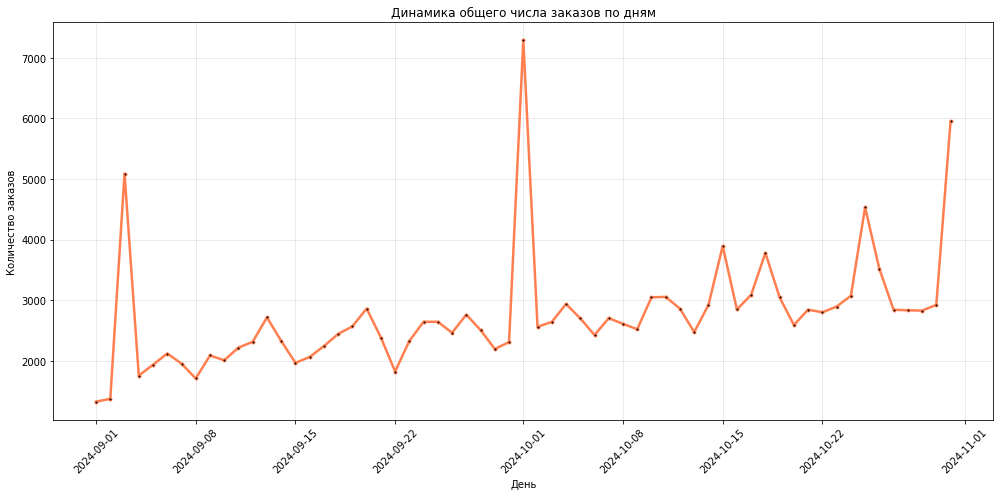

In [67]:
# Строим линейный график для общего числа заказов
plt.figure(figsize=(14, 7))
plt.plot(data['date'], data['total_orders'], marker='o', linewidth=2.5, markersize=3, 
         color='coral', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика общего числа заказов по дням')
plt.xlabel('День')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

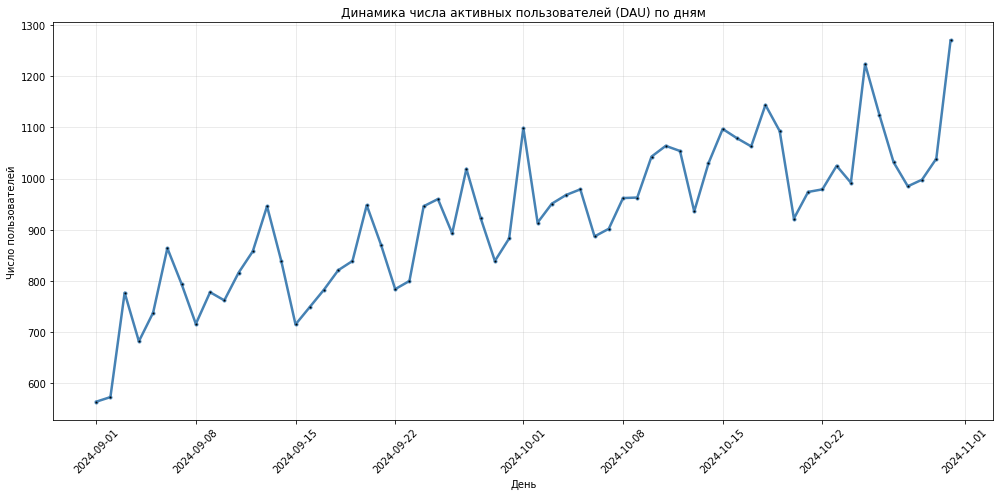

In [68]:
# Строим линейный график для общего числа заказов
plt.figure(figsize=(14, 7))
plt.plot(data['date'], data['DAU'], marker='o', linewidth=2.5, markersize=3, 
         color='steelblue', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика числа активных пользователей (DAU) по дням')
plt.xlabel('День')
plt.ylabel('Число пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

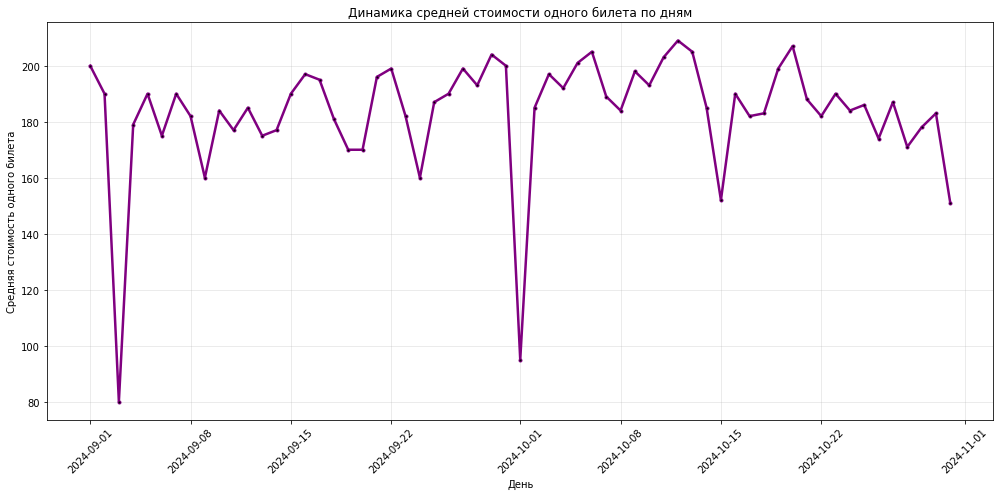

In [69]:
# Строим линейный график для общего числа заказов
plt.figure(figsize=(14, 7))
plt.plot(data['date'], data['avg_ticket_price'], marker='o', linewidth=2.5, markersize=3, 
         color='purple', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика средней стоимости одного билета по дням')
plt.xlabel('День')
plt.ylabel('Cредняя стоимость одного билета')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

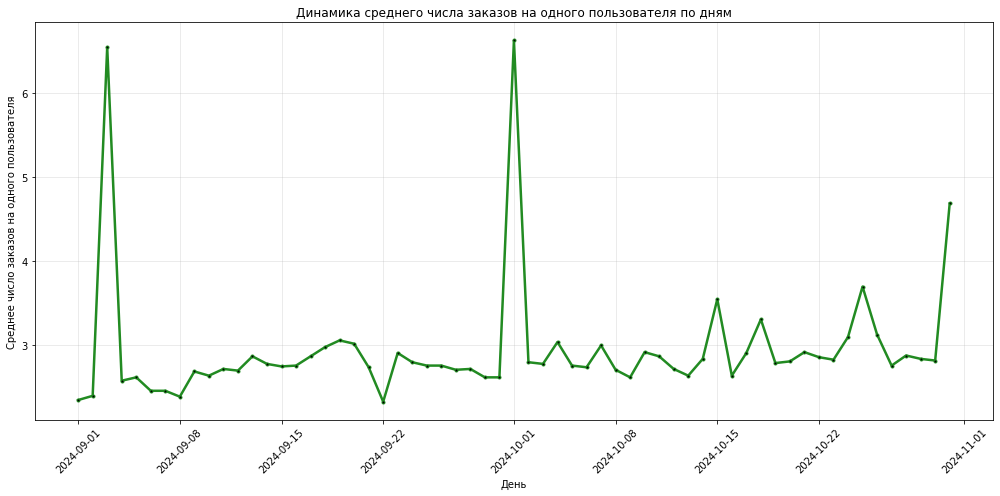

In [70]:
# Строим линейный график для общего числа заказов
plt.figure(figsize=(14, 7))
plt.plot(data['date'], data['orders_per_user'], marker='o', linewidth=2.5, markersize=3, 
         color='forestgreen', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика среднего числа заказов на одного пользователя по дням')
plt.xlabel('День')
plt.ylabel('Среднее число заказов на одного пользователя')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Анализ динамики активности рользователей осенью 2024 года**


- Динамика  общего числа заказов (total_orders):

Динамика общего числа заказов демонстрирует выраженную волнообразность с резкими пиками около 5000 заказов в начале сентября и около 7500 заказов начало октября. Наличие резких пиков  может быть связано с запуском маркетинговых кампаний, распродажами, праздниками или другими внешними событиями, которые стимулируют пользователей совершать больше покупок в определенные дни. 
Общий тренд — положительный, наблюдается постепенный рост заказов к октябрю-ноябрю.

- Динамика количества активных пользователей (DAU):

Динамика DAU демонстрирует выраженную скачкообразность на протяжении всего периода с постепенным ростом пользователей в осенние месяцы. Тренд - положительный, наблюдается постепенный рост пользователей к октябрю-ноябрю.

- Динамика среднего числа заказов на одного пользователя (orders_per_user):

Показатель демонстрирует колебательную динамику с несколькими ярко выраженными пиками и спадами на протяжении всего периода. 
В течение первой недели сентября происходит значительный рост  показателя до максимума, близкого к 7 заказам.Также резкий подъем наблюдается в начале октября, значение  также близкое к 7 заказам.
Наличие резких пиков может быть связано с запуском маркетинговых кампаний, распродажами, праздниками или другими внешними событиями, которые стимулируют пользователей совершать больше покупок в определенные дни.
Общий тренд -  в целом, метрика стабильна на протяжении всего периода.

- Динамика средней стоимости одного билета (avg_ticket_price):

Средний чек демонстрирует скачкообразную динамику с двумя резкими спадами цены: В начале сентября произошло снижение стоимости с 200 до 80 рублей и  в начале октября (снижение до 90-95 рублей), возможно в результате рекламных акций.
Общий тренд -  в целом, метрика стабильна на протяжении всего периода.

**Общий вывод**

Осенний период характеризуется положительной динамикой по ключевым метрикам - наблюдается рост общего числа заказов и количества активных пользователей к октябрю-ноябрю. При этом платформа демонстрирует неравномерную активность с выраженными всплесками, вероятно связанными с маркетинговыми кампаниями. Однако средняя стоимость заказа и вовлеченность пользователей остаются стабильными, что указывает на необходимость работы над удержанием клиентов и повышением лояльности.


In [71]:
# Создаем копию
df_autumn = df[df['season'] == 'осень'].copy()

# Создаем столбец с днем недели
df_autumn['day_of_week'] = df_autumn['created_dt_msk'].dt.dayofweek

# Создаем словарь для названий дней недели
weekdays = {
    0: 'понедельник',
    1: 'вторник', 
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
}

# Преобразуем номера дней недели в названия
df_autumn['days'] = df_autumn['day_of_week'].map(weekdays)

# Анализируем активность по дням недели
data = df_autumn.pivot_table(
    index=['days'],
    values=['order_id', 'user_id', 'one_ticket_revenue_rub'],
    aggfunc={
        'order_id': 'count',
        'user_id': 'nunique',
        'one_ticket_revenue_rub': 'mean'
    }
).reset_index()

# Передаем названия столбцам
data.columns = ['day', 'avg_ticket_price', 'total_orders', 'DAU']

# Рассчитаем среднее число заказов на одного пользователя
data['orders_per_user'] = (data['total_orders'] / data['DAU']).round(2)

# Задаем правильный порядок дней недели
day_order = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']

# Преобразуем столбец в категориальный с правильным порядком
data['day'] = pd.Categorical(data['day'], categories=day_order, ordered=True)

# Сортируем по правильному порядку дней
data = data.sort_values('day')

# Сбрасываем индекс для красоты
data = data.reset_index(drop=True)

# Выводим результат
display("Активность по дням недели:")
display(data)

'Активность по дням недели:'

,day,avg_ticket_price,total_orders,DAU,orders_per_user
0,понедельник,184.317120,21480,4440,4.84
1,вторник,140.735259,31418,4791,6.56
2,среда,186.111964,22824,4809,4.75
3,четверг,178.299245,27100,4963,5.46
4,пятница,185.825745,24778,4868,5.09
5,суббота,192.265002,21311,4565,4.67
6,воскресенье,198.132215,19366,4390,4.41


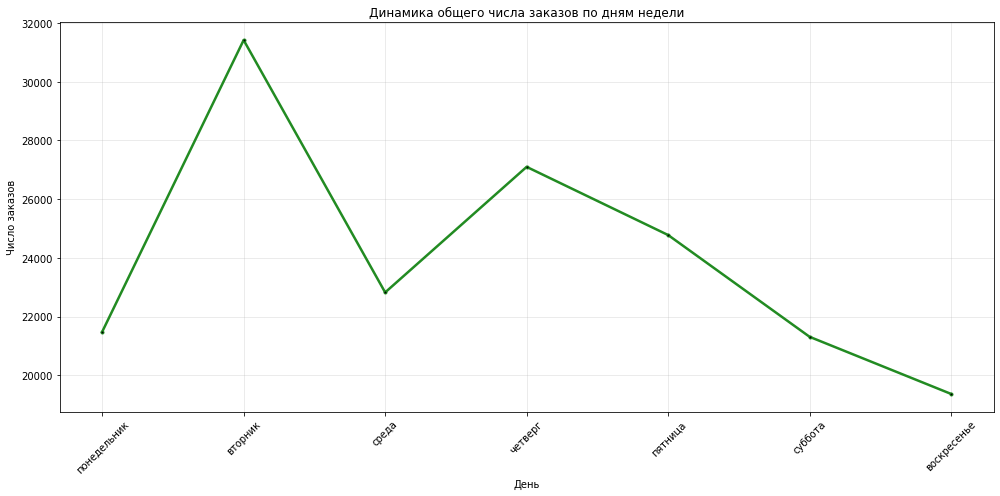

In [72]:
# Строим линейный график для общего числа заказов
plt.figure(figsize=(14, 7))
plt.plot(data['day'], data['total_orders'], marker='o', linewidth=2.5, markersize=3, 
         color='forestgreen', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика общего числа заказов по дням недели')
plt.xlabel('День')
plt.ylabel('Число заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

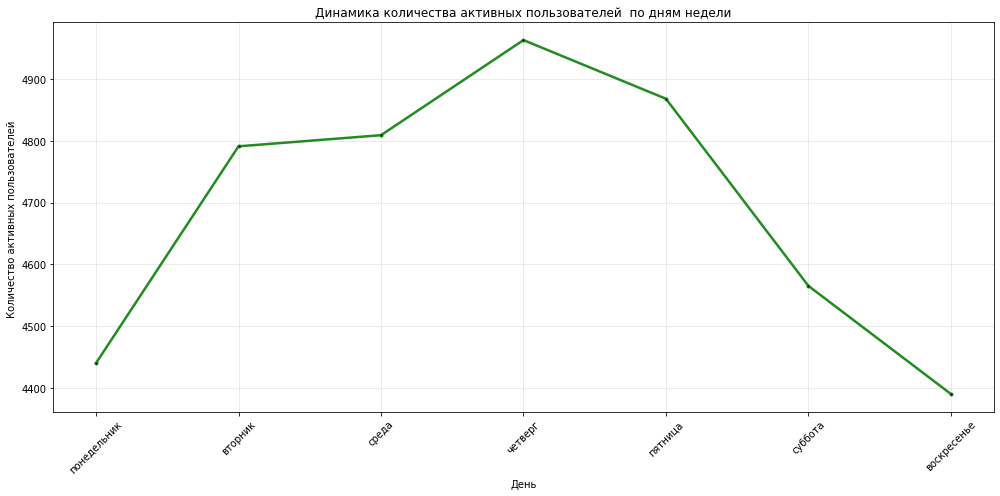

In [73]:
# Строим линейный график для количества активных пользователей 
plt.figure(figsize=(14, 7))
plt.plot(data['day'], data['DAU'], marker='o', linewidth=2.5, markersize=3, 
         color='forestgreen', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика количества активных пользователей  по дням недели')
plt.xlabel('День')
plt.ylabel('Количество активных пользователей ')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
data['orders_per_user'].head(10)

0    4.84
1    6.56
2    4.75
3    5.46
4    5.09
5    4.67
6    4.41
Name: orders_per_user, dtype: float64

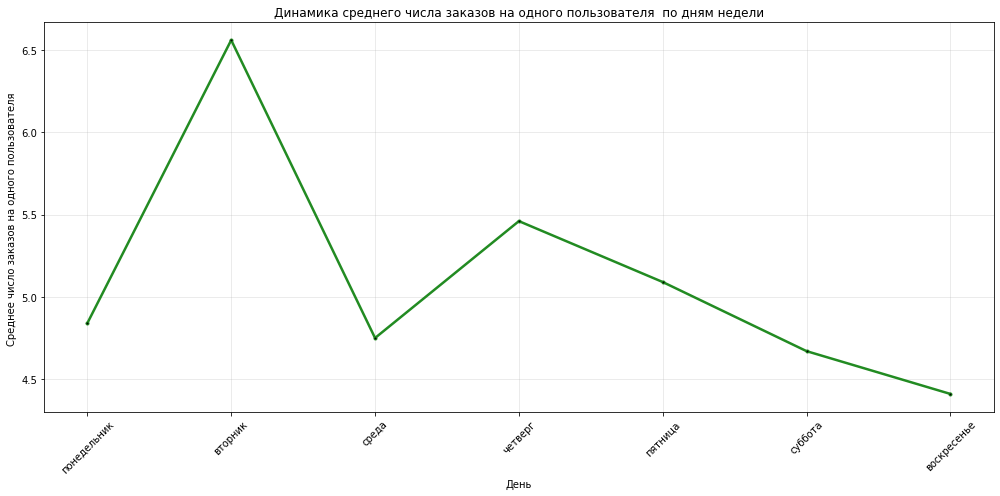

In [75]:
# Строим линейный график для среднего числа заказов на одного пользователя
plt.figure(figsize=(14, 7))
plt.plot(data['day'], data['orders_per_user'], marker='o', linewidth=2.5, markersize=3, 
         color='forestgreen', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика среднего числа заказов на одного пользователя  по дням недели')
plt.xlabel('День')
plt.ylabel('Среднее число заказов на одного пользователя ')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

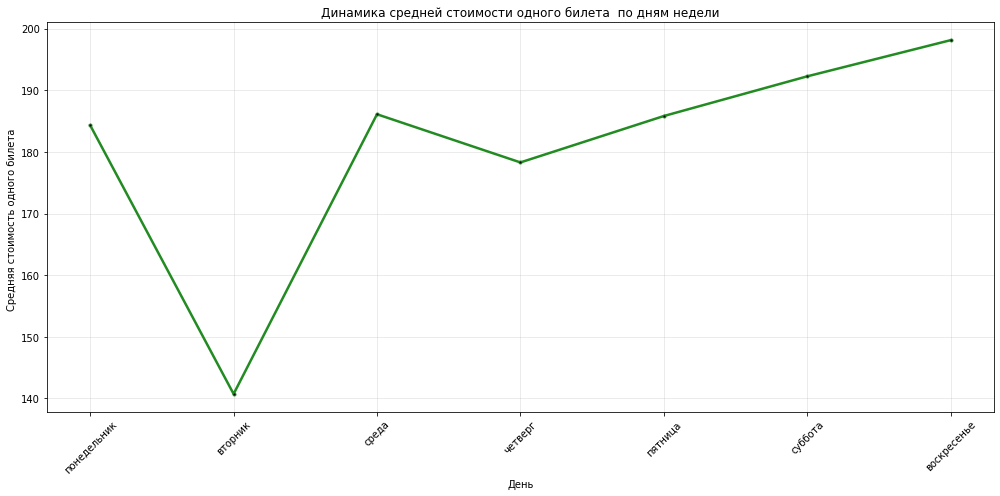

In [76]:
# Строим линейный график для средней стоимости одного билета
plt.figure(figsize=(14, 7))
plt.plot(data['day'], data['avg_ticket_price'], marker='o', linewidth=2.5, markersize=3, 
         color='forestgreen', markerfacecolor='black')

# Настраиваем график
plt.title('Динамика средней стоимости одного билета  по дням недели')
plt.xlabel('День')
plt.ylabel('Средняя стоимость одного билета ')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Промежуточный вывод.

**Анализ динамики пользовательской активности осенью 2024 года**


- Динамика общего числа заказов (total_orders):

Анализ графика показывает четкую недельную цикличность. Начало недели -  c понедельника на  вторник показывают резкий рост количества заказов, с спадом в среду, ростом в четверг и последующим спадом к выходным. Вторник  и четверг показывают максимальную активность. Наблюдается устойчивый паттерн: активность повышается  в будни и постепенно снижается к выходным.



- Динамика количества активных пользователей (DAU):

Количество активных пользователей возрастает в начале недели с пиком в четверг, с последующим спадом  к выходным. Дни повышенной активности - вторник и четверг. 

- Динамика среднего числа заказов на одного пользователя (orders_per_user):

Среднее число заказов на пользователя  возврастает с понедельника к вторнику , во вторник наблюдается пик (около 7 заказов), потом снижение в среду, рост в четверг и постепенное снижение к выходным. Дни повышенных покупок - вторник и четверг. В выходные спад активности.

- Динамика средней стоимости одного билета (avg_ticket_price):

График динамики средней стоимости одного билета по дням недели демонстрирует высокий уровень в понедельник , резкое падение во вторник, рост к среде, с  последующим ростом к выходным. 

**Вывод:**

Наблюдается четкое разделение активности между буднями и выходными днями. Будни (особенно вторник и четверг) демонстрируют пиковую активность по всем метрикам - количеству заказов, числу пользователей и их вовлеченности.Выходные дни показывают снижение пользовательской активности.


### 7.3 Популярные события и партнёры.


Посмотрим, как события осенью 2024 г. распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов.

In [77]:
# Анализ распределения мероприятий по регионам
region_data = df_autumn.pivot_table(
    index='region_name',
    values=['event_id', 'order_id'],
    aggfunc={
        'event_id': 'nunique',      # Уникальные мероприятия
        'order_id': 'count'        # Общее число заказов       
    }
).reset_index()

# Передаём названия столбцам
region_data.columns = ['region', 'unique_events', 'total_orders']

# Рассчитываем общее количество всех событий и заказов
total_events = region_data['unique_events'].sum()
total_orders_all = region_data['total_orders'].sum()

# Рассчитываем доли
region_data['events_share'] = (region_data['unique_events'] / total_events * 100).round(2)
region_data['orders_share'] = (region_data['total_orders'] / total_orders_all * 100).round(2)

# Сортируем сначала по событиям, потом по заказам
region_data = region_data.sort_values(['unique_events', 'total_orders'], ascending=[False, False])

display(f"Общее число уникальных событий: {total_events}")
display(f"Общее число заказов: {total_orders_all}" )
display("Распределение мероприятий и заказов по регионам:")
display(region_data.head(10))

'Общее число уникальных событий: 15834'

'Общее число заказов: 168277'

'Распределение мероприятий и заказов по регионам:'

,region,unique_events,total_orders,events_share,orders_share
23,Каменевский регион,3910,46669,24.69,27.73
59,Североярская область,2608,20641,16.47,12.27
75,Широковская область,796,8648,5.03,5.14
56,Светополянский округ,762,4770,4.81,2.83
51,Речиновская область,529,3564,3.34,2.12
60,Серебринская область,456,4467,2.88,2.65
76,Яблоневская область,431,4195,2.72,2.49
67,Тепляковская область,419,2485,2.65,1.48
11,Горицветская область,406,3230,2.56,1.92
63,Солнечноземская область,402,4197,2.54,2.49


Для каждого билетного партнёра (service_name) посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов:

In [78]:
# Анализ по билетным партнерам (service_name)
partner_data = df_autumn.pivot_table(
    index='service_name',
    values=['event_id', 'order_id', 'revenue_rub'],
    aggfunc={
        'event_id': 'nunique',      # Уникальные мероприятия
        'order_id': 'count',        # Количество заказов
        'revenue_rub': 'sum'        # Суммарная выручка
    }
).reset_index()

# Передаём названия столбцам
partner_data.columns = ['service_name', 'unique_events', 'total_orders', 'total_revenue']

# Рассчитываем общее количество всех событий и заказов, и общую выручку
total_events_all = partner_data['unique_events'].sum()
total_orders_all = partner_data['total_orders'].sum()
total_revenue_all = partner_data['total_revenue'].sum()

# Рассчитываем относительные количества (доли)
partner_data['events_share'] = (partner_data['unique_events'] / total_events_all * 100).round(2)
partner_data['orders_share'] = (partner_data['total_orders'] / total_orders_all * 100).round(2)
partner_data['revenue_share'] = (partner_data['total_revenue'] / total_revenue_all * 100).round(2)

# Сортируем сначала по событиям, потом по заказам
partner_data = partner_data.sort_values(['unique_events', 'total_orders'], ascending=[False, False])

display(f"Общее число уникальных событий: {total_events_all}")
display(f"Общее число заказов: {total_orders_all}")
display(f"Общая выручка:{total_revenue_all:.2f} руб")
display("Распределение мероприятий, заказов и выручки по билетным партнёрам:")
display(partner_data.head())

'Общее число уникальных событий: 17256'

'Общее число заказов: 168277'

'Общая выручка:81682334.27 руб'

'Распределение мероприятий, заказов и выручки по билетным партнёрам:'

,service_name,unique_events,total_orders,total_revenue,events_share,orders_share,revenue_share
21,Лови билет!,3611,25766,10375994.17,20.93,15.31,12.70
3,Билеты без проблем,2833,32242,12049853.45,16.42,19.16,14.75
5,Билеты в руки,2457,25643,7611672.96,14.24,15.24,9.32
25,Облачко,1409,15478,10611051.69,8.17,9.20,12.99
22,Лучшие билеты,1389,12399,1672813.64,8.05,7.37,2.05


### Промежуточный вывод.

**Распределение событий и заказов по регионам и партнерам осенью 2024 года.**


- Распределение по регионам: Общее число уникальных событий — 15 837, заказов — 168277. 

- Топ-2 региона:

- Каменевский — 46669 заказов, 24,69% событий, 27,73% заказов, Североярская область — 20641	заказов, 16,47% событий и 12,27% заказов. Доминируют, покрывая 41% событий и 40% заказов. 


- Распределение по партнерам: Общее число событий — 17 258, заказов — 168 339, выручка — 81,7 млн руб. 

- Топ-3 партнера:

- "Лови билет!" — 25766 заказов, 20,93% событий, 15,31% заказов, 12,70% выручки, "Билеты без проблем" — 32242 заказов, 16,42%, 19,16%, 14,75%, "Билеты в руки" — 25643 заказов, 14,24%, 15,24%, 9,32%) лидируют, охватывая 51% событий, 50% заказов и 37% выручки. 

**Явные лидеры по заказам:**

- Каменевский регион - явный лидер среди регионов.

- "Билеты без проблем"- явный лидер среди билетныx партнёров. 

Стоит продолжать с ними активно работать, но также развивать и других перспективных партнёров из топ-10, чтобы не зависеть только от этих двух.



<a id='якорь8'></a>

## 8. Статистический анализ данных


Коллеги из продуктового отдела хотят отдельно проверить несколько гипотез относительно активности пользователей мобильных и стационарных устройств. Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:


- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.


- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.


Таким образом ключевыми метриками будут:

- Среднее количество заказов на одного пользователя в мобильной  и декстопной версиях.

- Среднее время между заказами пользователей  в мобильной  и декстопной версиях.


### 8.1 Проверка первой гипотезы.

Для проверки первой гипотезы - "Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств" сформулируем нулевую (H0) и альтернативную гипотезу (H1):

- **H0:** Среднее количество заказов на одного пользователя мобильного приложения не превышает среднее количество заказов пользователей стационарных устройств.

    μ_b ≤ μ_a
    
где μ_a - среднее количество заказов десктопных пользователей,
    μ_b - среднее количество заказов мобильных пользователей
    
    
- **H1:** Существует статистически значимая разница в среднем количестве заказов между пользователями мобильного приложения и пользователями стационарных устройств, причем пользователи мобильного приложения совершают больше заказов.

     μ_b > μ_a

Группы, участвующие в эксперименте:
    
    - Группа A - пользователи декстопной версии - контрольная группа;
    
    - Группа B - пользователи мобильной версии - тестовая группа.
    
    
Определим размеры групп: Рассчитаем количество уникальных пользователей в каждой группе:

In [79]:
# Количество уникальных пользователей в группе A
A = df_autumn[df_autumn['device_type_canonical'] == 'desktop']['user_id'].nunique()

# Количество уникальных пользователей в группе B
B = df_autumn[df_autumn['device_type_canonical'] == 'mobile']['user_id'].nunique()

# Расчитаем процентную разницу в количестве пользователей в группах A и B
P = 100 * (abs(B - A))/B

display(f"Количество пользователей в группе A: {A}")
display(f"Количество пользователей в группе B: {B}")
display(f"Процентная разница: {P:.2f}%")

'Количество пользователей в группе A: 4866'

'Количество пользователей в группе B: 14175'

'Процентная разница: 65.67%'

Мы получили достаточно большую разницу в пользователях 85%, это может свидетельствовать о проблемах с разделением пользователей. Неравномерность групп может исказить результаты теста. Возможно, дело в пользователях, которые могли попасть в обе группы. Определим пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет:

In [80]:
# Выбираем всех пользователей из группы A
A = df_autumn[df_autumn['device_type_canonical'] == 'desktop']['user_id']

# Выбираем всех пользователей из группы B
B = df_autumn[df_autumn['device_type_canonical'] == 'mobile']['user_id']

# Преобразуем в множества и находим пересечение - пользователей, которые есть в обеих группах
intersection = list(set(A) & set(B))

# Выводим результат
display(intersection) # [] - пустой список означает, что пересечений нет

['9c91b8372bd1e46',
 '7b8ebb61f73c347',
 'f096340772f4c23',
 '47e76f5fc687d49',
 '1398a9f5e8b4ac8',
 '952263efdc63e5d',
 '1d9204aff100551',
 '68593d20f927af7',
 'c65516d4e07fa5d',
 'bdb757561a68530',
 'a5dac5d0538d62d',
 '66541f69c562b7c',
 'ddaefa229ce89cb',
 '9d3be7ca219193a',
 '1afe7ff378909c2',
 '463dc35b2daff7f',
 'aafb66ec2c9ea48',
 '364f53af13a8fe1',
 'a0d112e44a35fe5',
 '65cc93307ad8bf0',
 'd85ddb1633f07c5',
 '5b76f978285a661',
 'ad2dc32364ed948',
 'a9eec07fbea6ef2',
 '21b0708e338afb1',
 'aa7cb3b2dceb38d',
 '0618ff8395c4f85',
 '871a53e26a29e43',
 'c063fcc80ded9df',
 'f032093cab54085',
 '6bb7a7cdb2002cc',
 'de092b03b22533b',
 '3859e5fcdf8fe48',
 '4d7d76084933254',
 'bf4938b5f8f2d4d',
 'ead7a16c30232f0',
 '66a9035971673ee',
 'ccd00018804a932',
 'cdd2398f7788a8c',
 'acddb815a4ad10e',
 '2c34086146f8b61',
 'd1bb890fc18476a',
 '43442cd982405f8',
 'be881b922d13ba4',
 '7130bbbef44f7c8',
 '4de3ab2711a4751',
 'c2ee134c3f82da3',
 'b0e4026ab6da68a',
 'cfd21a3210b5a35',
 '3bfb9060ed61a76',


In [81]:
df_autumn = df_autumn[~df_autumn['user_id'].isin(intersection)]

In [82]:
# Количество уникальных пользователей в группе A
A = df_autumn[df_autumn['device_type_canonical'] == 'desktop']['user_id'].nunique()

# Количество уникальных пользователей в группе B
B = df_autumn[df_autumn['device_type_canonical'] == 'mobile']['user_id'].nunique()

# Расчитаем процентную разницу в количестве пользователей в группах A и B
P = 100 * (abs(B - A))/B


display(f"Количество пользователей в группе A: {A}")
display(f"Количество пользователей в группе B: {B}")
display(f"Процентная разница: {P:.2f}%")

'Количество пользователей в группе A: 1619'

'Количество пользователей в группе B: 10928'

'Процентная разница: 85.18%'

In [83]:
# Выбираем всех пользователей из группы A
A = df_autumn[df_autumn['device_type_canonical'] == 'desktop']['user_id']

# Выбираем всех пользователей из группы B
B = df_autumn[df_autumn['device_type_canonical'] == 'mobile']['user_id']

# Преобразуем в множества и находим пересечение - пользователей, которые есть в обеих группах
intersection = list(set(A) & set(B))

# Выводим результат
display(intersection) # [] - пустой список означает, что пересечений нет

[]

### 8.2 Расчет ключевых метрик.

Перед проведением гипотез изучим сравниваемые данные. Работать будем с датафреймом только за осенний период `df_autumn`.

Разделим данные за осенний период по типу устройств и посчитаем среднее количество заказов на одного пользователя и среднее время между заказами пользователей:

In [84]:
# Разделяем данные по типу устройства
df_mobile = df_autumn[df_autumn['device_type_canonical'] == 'mobile'].copy()
df_desktop = df_autumn[df_autumn['device_type_canonical'] == 'desktop'].copy()

# Группируем по user_id и считаем количество заказов для каждого пользователя
mobile_orders_per_user = df_mobile.groupby('user_id')['order_id'].count()
desktop_orders_per_user = df_desktop.groupby('user_id')['order_id'].count()

# Добавляем столбцы в датафреймы
df_mobile['mobile_orders_per_user '] = mobile_orders_per_user 
df_desktop['desktop_orders_per_user'] = desktop_orders_per_user

display(df_mobile.head(3))
display(df_desktop.head(3))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_address,date,exchange_rate,revenue_rub,one_ticket_revenue_rub,month,season,day_of_week,days,mobile_orders_per_user
42,5009432,06c73b84b2405f3,2024-10-26,2024-10-26 16:11:24,237325,нет,0,rub,mobile,578.90,...,"алл. Шмидта, д. 9 стр. 4",2024-10-26,0.199266,578.90,144.72,10,осень,5,суббота,NaN
43,2790149,087a90accc1e4b0,2024-10-27,2024-10-27 11:23:38,237325,нет,0,rub,mobile,434.18,...,"алл. Шмидта, д. 9 стр. 4",2024-10-27,0.199266,434.18,144.73,10,осень,6,воскресенье,NaN
60,3643242,35033a947748839,2024-10-20,2024-10-20 14:51:16,237325,нет,0,rub,mobile,144.73,...,"алл. Шмидта, д. 9 стр. 4",2024-10-20,0.197884,144.73,144.73,10,осень,6,воскресенье,NaN


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_address,date,exchange_rate,revenue_rub,one_ticket_revenue_rub,month,season,day_of_week,days,desktop_orders_per_user
19,4173884,1a7e020ee0b4418,2024-10-11,2024-10-11 18:14:13,169230,нет,16,rub,desktop,1141.45,...,"алл. Машиностроителей, д. 19 стр. 6",2024-10-11,0.198829,1141.45,380.48,10,осень,4,пятница,NaN
467,7439081,60d03b94792877d,2024-09-03,2024-09-03 22:11:28,509453,нет,18,rub,desktop,926.94,...,"ш. Набережное, д. 595 стр. 8",2024-09-03,0.186868,926.94,463.47,9,осень,1,вторник,NaN
491,3836962,69ff64858357a2b,2024-10-16,2024-10-16 09:06:51,509453,нет,18,rub,desktop,1853.87,...,"ш. Набережное, д. 595 стр. 8",2024-10-16,0.200393,1853.87,463.47,10,осень,2,среда,NaN


Ключевые метрики посчитаны

При помощи метода `.describe()` выведем статистику по группам:

In [85]:
# Статистика группы B
mobile_stats = mobile_orders_per_user.describe()

# Выводим результат
display("Статистика группы В")
display(mobile_stats)

# Статистика группы A
desktop_stats = desktop_orders_per_user.describe()

display("Статистика группы А")
display(desktop_stats)


'Статистика группы В'

count    10928.000000
mean         2.857247
std          4.097549
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
Name: order_id, dtype: float64

'Статистика группы А'

count    1619.000000
mean        1.974058
std         3.061273
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        56.000000
Name: order_id, dtype: float64

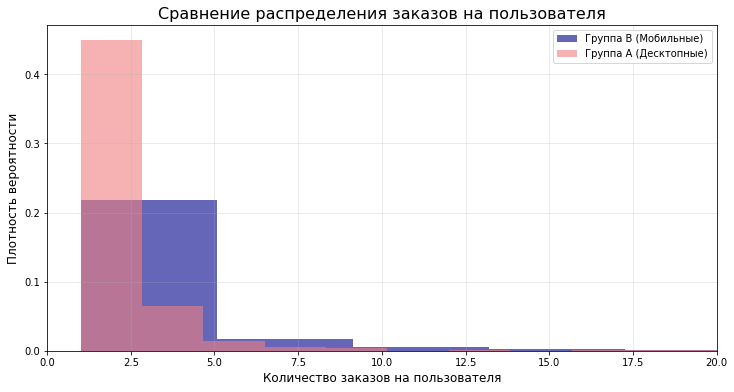

In [86]:
# Построим гистограмму
plt.figure(figsize=(12, 6))


plt.hist(mobile_orders_per_user, bins=30, alpha=0.6, color='darkblue', label='Группа B (Мобильные)', density=True)
plt.hist(desktop_orders_per_user, bins=30, alpha=0.6, color='lightcoral', label='Группа A (Десктопные)', density=True)

plt.title('Сравнение распределения заказов на пользователя', fontsize=16)
plt.xlabel('Количество заказов на пользователя', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.show()

**Распределение количества заказов на одного пользователя**


- Мобильная версия (группа B): Распределение характеризуется правосторонней асимметрией из-за высокого максимума (123 заказа) и значительного стандартного отклонения (4,10). Большинство пользователей (50%) совершают 1–2 заказа (медиана 2), но 25% доходят до 3 заказов, а редкие пользователи (выбросы) значительно увеличивают среднее (2,86). Это говорит о том, что основная масса пользователей делает 1–3 заказа, с длинным "хвостом" из активных исключений.


- Десктопная версия (группа A): Распределение также асимметрично, но менее выражено (максимум 56, std 3,06). Медиана (1 заказ) показывает, что половина пользователей ограничивается одним заказом, 25% доходят до 2, а среднее (1,97) слегка смещено из-за выбросов. 

**Вывод:**

Распределение количества заказов на одного пользователя в обоих группах несимметрично, с тяжёлым правым хвостом из-за выбросов.


In [87]:
variance_m = mobile_orders_per_user.var()
variance_d = desktop_orders_per_user.var()

display("Дисперсия по группам:")
display(f"Дисперсия группы А: {variance_d:.2f}")
display(f"Дисперсия группы B: {variance_m:.2f}")

'Дисперсия по группам:'

'Дисперсия группы А: 9.37'

'Дисперсия группы B: 16.79'

Дисперсия в группах не одинакова.

Исследуем на выбросы. Чтобы показать выбросы, удобнее всего использовать диаграмму размаха, или «ящик с усами» (boxplot()):

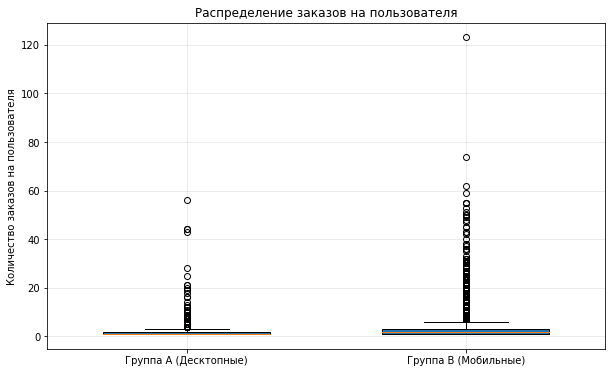

In [88]:
# Построим boxplot для проверки выбросов
plt.figure(figsize=(10, 6))

# Собираем данные для boxplot
data_to_plot = [desktop_orders_per_user, mobile_orders_per_user]
labels = ['Группа A (Десктопные)', 'Группа B (Мобильные)']

# Создаем boxplot
boxplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)
plt.title('Распределение заказов на пользователя')
plt.ylabel('Количество заказов на пользователя')
plt.grid(True, alpha=0.3)
plt.show()

Наблюдается значительное количество выбросов. Это множество точек за верхней границей усов.

**Выбор статистического теста.**

В связи со значительной разницей в размерах выборок (1619 и 10928) и неравенством дисперсий (9,37 и 16.79), а также наличием правосторонней асимметрии в распределениях выборочных средних, а также выбросов  которые нарушают ключевые предположения стандартного t-теста, для корректной проверки гипотезы выбираем теста Манна — Уитни , поскольку  он нечувствителен к выбросам из-за рангового преобразования.

In [89]:
alpha = 0.05 # на каком уровне значимости проверяем гипотезу о равенстве выборочных средних

# Данные для теста
group_a = desktop_orders_per_user  # Десктоп
group_b = mobile_orders_per_user   # Мобильные
stat_mannwhitney, p_value_mannwhitney = mannwhitneyu(
    group_b,
    group_a,
    alternative='greater'  # Проверяем что B > A
)

if p_value_mannwhitney > alpha:
    display(f"p-value {p_value_mannwhitney} > {alpha}")
    display("Нет оснований отвергнуть нулевую гипотезу.")
    display("Статистически значимых свидетельств того, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, не обнаружено")
else:
    display(f"p-value {p_value_mannwhitney} < {alpha}") 
    display("Можем отвергнуть нулевую гипотезу.")
    display("Есть статистически значимые свидетельства того, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств")


'p-value 6.421312899366994e-39 < 0.05'

'Можем отвергнуть нулевую гипотезу.'

'Есть статистически значимые свидетельства того, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств'

**Промежуточный вывод по проверке первой гипотезы.**

Результат теста Манна — Уитни для проверки гипотезы о том, что среднее количество заказов на одного пользователя мобильного приложения (группа B) выше, чем у пользователей стационарных устройств (группа A), показал значение p-value = 6,42e-39, что значительно ниже установленного уровня значимости α = 0,05. Это позволяет отвергнуть нулевую гипотезу (H0: μ_a = μ_b) в пользу альтернативной гипотезы (H1: μ_b > μ_a).

### 8.3 Проверка второй гипотезы.

Для проверки второй гипотезы - "Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств." сформулируем нулевую (H0) и альтернативную гипотезу (H1):

- **H0:** Среднее время между заказами пользователей мобильного приложения не превышает среднее время между заказами пользователей стационарных устройств.

    μ_b ≤ μ_a

где μ_a - среднее время между заказами десктопных пользователей, μ_b - среднее время между заказами мобильных пользователей

- **H1:** Существует статистически значимая разница в среднем времени между заказами пользователей мобильного приложения и пользователей стационарных устройств, причем среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

μ_b > μ_a

In [90]:
# Применяем метод describe() к столбцу 'days_since_prev' для мобильных пользователей
display("Статистика для среднего времени между заказами пользователей мобильной версии:")
display(df_mobile['days_since_prev'].describe())

# Для десктопных пользователей
display("Статистика для среднего времени между заказами пользователей декстопной версии:")
display(df_desktop['days_since_prev'].describe())

'Статистика для среднего времени между заказами пользователей мобильной версии:'

count    24551.000000
mean        13.781475
std         25.706662
min          0.000000
25%          0.000000
50%          1.000000
75%         15.000000
max        148.000000
Name: days_since_prev, dtype: float64

'Статистика для среднего времени между заказами пользователей декстопной версии:'

count    2078.000000
mean       18.074591
std        32.669627
min         0.000000
25%         0.000000
50%         0.000000
75%        22.000000
max       146.000000
Name: days_since_prev, dtype: float64

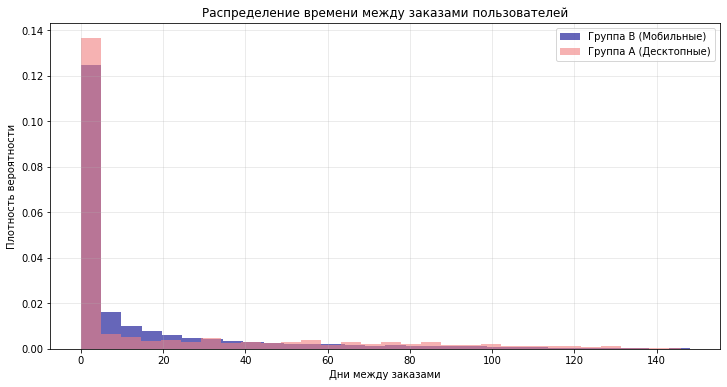

In [91]:
# Построим гистограмму распределения
mobile_days = df_mobile['days_since_prev']
desktop_days = df_desktop['days_since_prev']

plt.figure(figsize=(12, 6))
plt.hist(mobile_days, bins=30, alpha=0.6, color='darkblue', label='Группа B (Мобильные)', density=True)
plt.hist(desktop_days, bins=30, alpha=0.6, color='lightcoral', label='Группа A (Десктопные)', density=True)
plt.title('Распределение времени между заказами пользователей')
plt.xlabel('Дни между заказами')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3) 
plt.show()

**Анализ распределения времени между заказами пользователей по группам.**


Мобильная версия (группа B): 

- Среднее 13.78 дней; 

- Медиана (50%) 1 день; 

- Cтандартное отклонение 25.71 дней (широкий разброс);  

- Mаксимум 148 дней; 

- Наличие 25% значений в 0 дней и 75% перцентиля в 15 дней указывает на скошенное вправо распределение;


Десктопная версия (группа А): 

- Среднее 18.07 дней; 

- Медиана (50%) 0 дней;

- Стандартное отклонение 32.67 ( с ещё большим разбросом); 

- Mаксимум 146 дней; 

- 25% значений в 0 дней и 75% перцентиль в 22 дня также предполагают скошенное вправо распределение, с более выраженной хвостовой частью из-за редких, но значительных интервалов.


**Вывод**

Оба распределения имеют асимметрию из-за наличия нулей (мгновенные повторные заказы) и длинного хвоста (редкие большие интервалы). 


Определим дисперсии в обоих группах:

In [92]:
# Вычисление дисперсии
variance_m = mobile_days.var()
variance_d = desktop_days.var()

# Вывод результата
display("Дисперсия по группам:")
display(f"Дисперсия группы А: {variance_d:.2f}")
display(f"Дисперсия группы B: {variance_m:.2f}")


'Дисперсия по группам:'

'Дисперсия группы А: 1067.30'

'Дисперсия группы B: 660.83'

Дисперсии в группе A и B не одинаковы.

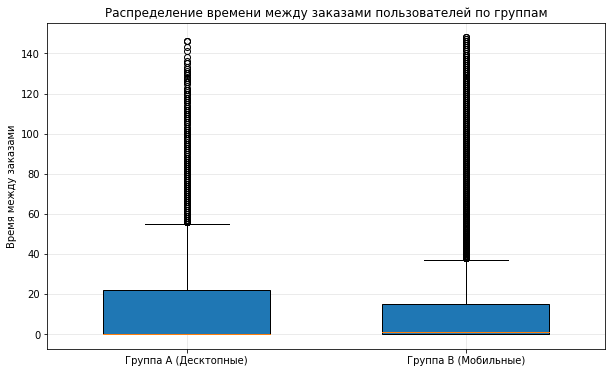

In [93]:
#Очистим от пропусков
mobile_days = mobile_days.dropna()
desktop_days = desktop_days.dropna()
# Построим boxplot для проверки выбросов
plt.figure(figsize=(10, 6))

# Собираем данные для boxplot
data_to_plot = [desktop_days, mobile_days]
labels = ['Группа A (Десктопные)', 'Группа B (Мобильные)']

# Создаем boxplot
boxplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)
plt.title('Распределение времени между заказами пользователей по группам')
plt.ylabel('Время между заказами')
plt.grid(True, alpha=0.3)
plt.show()


Наблюдается значительное количество выбросов. Это множество точек за верхней границей усов.

**Выбор статистического теста.**

В связи со значительной разницей в размерах выборок (1619 и 10928) и неравенством дисперсий (1067.30 и 660.83 ), а также наличием правосторонней асимметрии в распределениях выборочных средних,  а также выбросов которые нарушают ключевые предположения стандартного t-теста, для корректной проверки гипотезы выбираем теста Манна — Уитни , поскольку он нечувствителен к выбросам из-за рангового преобразования.

In [94]:
alpha = 0.05 # на каком уровне значимости проверяем гипотезу о равенстве выборочных средних

# Данные для теста (преобразованы в часы)
group_a = desktop_days   # Десктоп
group_b = mobile_days    # Мобильные
stat_mannwhitney, p_value_mannwhitney = mannwhitneyu(
    group_b,
    group_a,
    alternative='greater'  # Проверяем что B > A
)

if p_value_mannwhitney > alpha:
    display(f"p-value {p_value_mannwhitney} > {alpha}")
    display("Нет оснований отвергнуть нулевую гипотезу.")
    display("Статистически значимых свидетельств того, что среднее время  между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств, не обнаружено")
else:
    display(f"p-value {p_value_mannwhitney} < {alpha}") 
    display("Можем отвергнуть нулевую гипотезу.")
    display("Есть статистически значимые свидетельства того, что среднее время  между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств")

'p-value 5.9471299775592325e-08 < 0.05'

'Можем отвергнуть нулевую гипотезу.'

'Есть статистически значимые свидетельства того, что среднее время  между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств'

**Промежуточный вывод по проверке второй гипотезы**


Результат теста Манна — Уитни для проверки гипотезы о том, что среднее время между заказами пользователей мобильного приложения (группа B) выше, чем у пользователей стационарных устройств (группа A), показал значение p-value = 5,95e-24, что значительно ниже установленного уровня значимости α = 0,05. Это позволяет отвергнуть нулевую гипотезу (H0: μ_a = μ_b) в пользу альтернативной гипотезы (H1: μ_b > μ_a).



<a id='якорь9'></a>
## 9. Общий вывод.


**Информация о данных**


В проекте анализировались данные сервиса Яндекс Афиши за период с 1 июня по 30 ноября 2024 года из трёх датасетов: `final_tickets_orders_df.csv` (290 849 записей о заказах билетов, включая user_id, order_id, event_id, device_type_canonical, revenue, tickets_count), `final_tickets_events_df.csv` (22 427 записей о событиях, включая event_type_main, age_limit, region_name) и `final_tickets_tenge_df.csv` (курсы тенге к рублю). После очистки (удаление 1.78% данных: выбросов, отрицательной выручки, дубликатов) и объединения, получен датасет с 287 133 записями. Добавлены столбцы: revenue_rub (выручка в рублях), one_ticket_revenue_rub (выручка с билета), month и season (сезонность).


**Основные результаты анализа**


Наиболее востребованы концерты (43% заказов летом, 37% осенью), "другое" (27% летом, 20% осенью) и театр (20% летом, 25% осенью). Осенью популярность концертов снижается в доле, но растёт в абсолютных количествах заказов (с 50 753 до 62 683 заказов); театр и спорт набирают (театр: +5%, спорт: +8%), ёлки появляются (1%). Средний чек снижается осенью для концертов (-12%, до 268 руб.), театра (-18%, до 176 руб.) и ёлок (-15%, до 230 руб.), но растёт для стендапа (+6%, до 231 руб.) и выставок (+6%, до 92 руб.), указывая на сдвиг к доступным мероприятиям. 
Пользовательская активность осенью растёт: заказы +50% (с 118 856 до 168 277), DAU стабильно  около 5 000, orders_per_user около 0.1 (однократные покупки), avg_ticket_price 1 000–1 500 руб. Наиболее перспективными днями с точки зрения одновременного роста нескольких метрик являются вторник и четверг, когда наблюдается синхронный рост DAU и других показателей.
Мобильные устройства доминируют (80–81%), с ростом заказов +40%. 
Лидеры: Каменевский регион (28% заказов, 25% событий), Североярская область (12% заказов), партнёры "Лови билет!" (15% заказов, 13% выручки) и "Билеты без проблем" (19% заказов, 15% выручки), топ-3 охватывают 50% заказов и 37% выручки (81.7 млн руб. общая). Семейные рейтинги (0 и 12) растут осенью (+6% вместе).

**Комментарий к результатам проверки гипотез**


Обе гипотезы подтверждены тестом Манна — Уитни  (α=0.05). Первая: Среднее заказов в мобильной версии выше (p-value = 6,42e-39), подтверждая большую вовлечённость. Вторая: Среднее время между заказами в мобильной версии выше (p-value = 5,95e-24), указывая на интервальную модель поведения. Учёт неравенства дисперсий и размеров групп (10 928 и 1 619) обеспечил надёжность.

**Рекомендации**


- Обратить внимание на мобильных пользователей: оптимизировать приложение для повторных покупок (уведомления, лояльность-программы), так как интервалы длиннее, но заказов больше. 

- Адаптировать цены осенью (скидки на концерты/театр), продвигать спорт и театр. 

- Улучшить сотрудничество с лидерами. 

- Расширить круг сотрудничества, включив в него ещё девять важных партнёров (топ-10). Это поможет снизить зависимость от одного партнёра и сделать сотрудничество более устойчивым и разнообразным.

- Анализировать будничные пики (вторник и четверг) для более точного направления маркетинговых усилий. Исследовать выбросы (максимальное количество заказов — 123) для выявления лояльных сегментов клиентов.

- Провести A/B-тесты по сезонам для повышения среднего чека.
